In [5]:
from pathlib import Path
import pandas as pd

# Your MIMIC-IV folder
MIMIC_ROOT = Path(
    r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1"
)

rows = []
errors = []

# Finds .csv and compressed .csv.gz files inside hosp/ and icu/
csv_files = sorted(MIMIC_ROOT.rglob("*.csv*"))

for csv_path in csv_files:
    try:
        # Read only the header + first row, not the full giant file
        df = pd.read_csv(csv_path, nrows=1)

        print("\n" + "=" * 90)
        print(f"FILE: {csv_path.relative_to(MIMIC_ROOT)}")
        print("=" * 90)

        for column in df.columns:
            dtype = df[column].dtype
            first_value = df[column].iloc[0]

            print(f"{column}  -  {dtype}  -  {first_value}")

    except Exception as error:
        print(f"\nCould not read {csv_path.name}: {error}")


FILE: hosp\admissions.csv.gz
subject_id  -  int64  -  10000032
hadm_id  -  int64  -  22595853
admittime  -  str  -  2180-05-06 22:23:00
dischtime  -  str  -  2180-05-07 17:15:00
deathtime  -  float64  -  nan
admission_type  -  str  -  URGENT
admit_provider_id  -  str  -  P49AFC
admission_location  -  str  -  TRANSFER FROM HOSPITAL
discharge_location  -  str  -  HOME
insurance  -  str  -  Medicaid
language  -  str  -  English
marital_status  -  str  -  WIDOWED
race  -  str  -  WHITE
edregtime  -  str  -  2180-05-06 19:17:00
edouttime  -  str  -  2180-05-06 23:30:00
hospital_expire_flag  -  int64  -  0

FILE: hosp\d_hcpcs.csv.gz
code  -  int64  -  0
category  -  float64  -  nan
long_description  -  float64  -  nan
short_description  -  str  -  Invalid Code

FILE: hosp\d_icd_diagnoses.csv.gz
icd_code  -  int64  -  10
icd_version  -  int64  -  9
long_title  -  str  -  Cholera due to vibrio cholerae

FILE: hosp\d_icd_procedures.csv.gz
icd_code  -  int64  -  1
icd_version  -  int64  -  9
lo

In [6]:
from pathlib import Path
import pandas as pd

MIMIC_ROOT = Path(
    r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1"
)

# This works whether Windows hides the .gz extension or not
admissions_path = next(
    (MIMIC_ROOT / "hosp").glob("admissions.csv*")
)

admissions = pd.read_csv(
    admissions_path,
    usecols=[
        "subject_id",
        "hadm_id",
        "admittime",
        "dischtime",
        "deathtime",
        "hospital_expire_flag",
        "admission_type",
        "admission_location",
        "discharge_location",
        "insurance",
        "language",
        "marital_status",
        "race",
    ],
    parse_dates=["admittime", "dischtime", "deathtime"],
)

admissions.head()

,subject_id,hadm_id,admittime,dischtime,deathtime,admission_type,admission_location,discharge_location,insurance,language,marital_status,race,hospital_expire_flag
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,NaT,URGENT,TRANSFER FROM HOSPITAL,HOME,Medicaid,English,WIDOWED,WHITE,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,NaT,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,0
2,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,EW EMER.,EMERGENCY ROOM,HOSPICE,Medicaid,English,WIDOWED,WHITE,0
3,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,NaT,EW EMER.,EMERGENCY ROOM,HOME,Medicaid,English,WIDOWED,WHITE,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaT,EU OBSERVATION,EMERGENCY ROOM,NaN,NaN,English,SINGLE,WHITE,0


In [7]:
# Put every patient's admissions in time order
admissions = admissions.sort_values(
    ["subject_id", "admittime"]
).reset_index(drop=True)

# For each patient, get the next hospital admission after this one
admissions["next_admittime"] = (
    admissions.groupby("subject_id")["admittime"]
    .shift(-1)
)

# Time from THIS discharge to THAT next admission
admissions["days_to_next_admission"] = (
    admissions["next_admittime"] - admissions["dischtime"]
).dt.total_seconds() / (60 * 60 * 24)

# A patient who died in this hospitalization cannot be readmitted.
eligible_for_readmission = (
    admissions["hospital_expire_flag"].eq(0)
    & admissions["deathtime"].isna()
)

# 1 = next hospital admission was within 30 days after discharge
admissions["readmit_30d"] = (
    eligible_for_readmission
    & admissions["days_to_next_admission"].between(0, 30, inclusive="both")
).astype(int)

admissions[
    [
        "subject_id",
        "hadm_id",
        "admittime",
        "dischtime",
        "next_admittime",
        "days_to_next_admission",
        "readmit_30d",
    ]
].head(15)

,subject_id,hadm_id,admittime,dischtime,next_admittime,days_to_next_admission,readmit_30d
0,10000032,22595853,2180-05-06 22:23:00,2180-05-07 17:15:00,2180-06-26 18:27:00,50.050000,0
1,10000032,22841357,2180-06-26 18:27:00,2180-06-27 18:49:00,2180-07-23 12:35:00,25.740278,1
2,10000032,29079034,2180-07-23 12:35:00,2180-07-25 17:55:00,2180-08-05 23:44:00,11.242361,1
3,10000032,25742920,2180-08-05 23:44:00,2180-08-07 17:50:00,NaT,NaN,0
4,10000068,25022803,2160-03-03 23:16:00,2160-03-04 06:26:00,NaT,NaN,0
5,10000084,23052089,2160-11-21 01:56:00,2160-11-25 14:52:00,2160-12-28 05:11:00,32.596528,0
6,10000084,29888819,2160-12-28 05:11:00,2160-12-28 16:07:00,NaT,NaN,0
7,10000108,27250926,2163-09-27 23:17:00,2163-09-28 09:04:00,NaT,NaN,0
8,10000117,22927623,2181-11-15 02:05:00,2181-11-15 14:52:00,2183-09-18 18:10:00,672.137500,0
9,10000117,27988844,2183-09-18 18:10:00,2183-09-21 16:30:00,NaT,NaN,0


In [8]:
print(admissions["readmit_30d"].value_counts())

print("\nPercent readmitted within 30 days:")
print(
    admissions["readmit_30d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

readmit_30d
0    436685
1    109343
Name: count, dtype: int64

Percent readmitted within 30 days:
readmit_30d
0    79.97
1    20.03
Name: proportion, dtype: float64


In [9]:
icustays_path = next(
    (MIMIC_ROOT / "icu").glob("icustays.csv*")
)

icustays = pd.read_csv(
    icustays_path,
    parse_dates=["intime", "outtime"],
)

# If an admission had multiple ICU stays, use its first ICU stay as its index ICU stay.
index_icu_stays = (
    icustays
    .sort_values(["hadm_id", "intime"])
    .drop_duplicates(subset="hadm_id", keep="first")
)

readmit_cohort = index_icu_stays.merge(
    admissions[
        [
            "subject_id",
            "hadm_id",
            "readmit_30d",
            "days_to_next_admission",
            "admittime",
            "dischtime",
        ]
    ],
    on=["subject_id", "hadm_id"],
    how="inner",
)

print(readmit_cohort.shape)
readmit_cohort[["subject_id", "hadm_id", "intime", "readmit_30d"]].head()

(85242, 12)


,subject_id,hadm_id,intime,readmit_30d
0,14046553,20000094,2150-03-02 15:19:31,0
1,14990224,20000147,2121-08-30 16:33:54,0
2,17913090,20000351,2145-06-13 20:10:27,0
3,16788749,20000808,2180-01-12 22:07:00,0
4,15583900,20000916,2162-08-13 03:26:53,0


In [10]:
readmit_cohort.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,readmit_30d,days_to_next_admission,admittime,dischtime
0,14046553,20000094,35605481,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2150-03-02 15:19:31,2150-03-03 11:28:38,0.839664,0,NaN,2150-03-02 00:00:00,2150-03-03 09:21:00
1,14990224,20000147,30503572,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2121-08-30 16:33:54,2121-08-31 21:29:49,1.205498,0,788.34375,2121-08-30 16:33:00,2121-09-03 15:45:00
2,17913090,20000351,30593599,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2145-06-13 20:10:27,2145-06-14 16:49:38,0.860544,0,NaN,2145-06-13 02:09:00,2145-06-18 17:52:00
3,16788749,20000808,35191063,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2180-01-12 22:07:00,2180-01-13 13:36:47,0.645683,0,NaN,2180-01-12 20:59:00,2180-01-25 12:10:00
4,15583900,20000916,39464752,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2162-08-13 03:26:53,2162-08-13 20:54:23,0.727431,0,NaN,2162-08-13 01:57:00,2162-08-18 04:30:00


In [11]:
# Days from discharge to death, when a death date is available
admissions["days_to_death"] = (
    admissions["deathtime"] - admissions["dischtime"]
).dt.total_seconds() / (60 * 60 * 24)

# These patients cannot have a 30-day readmission:
# - died in the hospital
# - died after discharge but within the next 30 days
died_before_readmission_window_ends = (
    admissions["hospital_expire_flag"].eq(1)
    | admissions["days_to_death"].between(0, 30, inclusive="both")
)

# Create the label only for patients eligible to experience readmission
admissions["readmit_30d"] = pd.NA

eligible = ~died_before_readmission_window_ends

admissions.loc[eligible, "readmit_30d"] = (
    admissions.loc[eligible, "days_to_next_admission"]
    .between(0, 30, inclusive="both")
    .astype(int)
)

admissions["readmit_30d"] = admissions["readmit_30d"].astype("Int64")

In [12]:
readmit_cohort = readmit_cohort.dropna(subset=["readmit_30d"]).copy()

In [13]:
print("ICU cohort shape:", readmit_cohort.shape)

print("\nOne row per hospital admission?")
print(readmit_cohort["hadm_id"].is_unique)

print("\nReadmission balance for ICU patients only:")
print(readmit_cohort["readmit_30d"].value_counts())

print("\nReadmission percentage for ICU patients only:")
print(
    readmit_cohort["readmit_30d"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

ICU cohort shape: (85242, 12)

One row per hospital admission?
True

Readmission balance for ICU patients only:
readmit_30d
0    69821
1    15421
Name: count, dtype: int64

Readmission percentage for ICU patients only:
readmit_30d
0    81.91
1    18.09
Name: proportion, dtype: float64


In [14]:
baseline_accuracy = (readmit_cohort["readmit_30d"] == 0).mean()

print(f"Always predict no-readmission accuracy: {baseline_accuracy:.2%}")
print("Always predict no-readmission recall: 0.00%")

# Accuracy is not priority metric of concern for model

Always predict no-readmission accuracy: 81.91%
Always predict no-readmission recall: 0.00%


In [15]:
# Make sure admissions are ordered within each patient
admissions = admissions.sort_values(
    ["subject_id", "admittime"]
).reset_index(drop=True)

# ---------------------------------------------------
# 1. Basic hospital-history features
# ---------------------------------------------------

# Number of admissions before the current admission
admissions["prior_admission_count"] = (
    admissions.groupby("subject_id").cumcount()
)

# Hospital length of stay for each admission
admissions["hospital_los_days"] = (
    admissions["dischtime"] - admissions["admittime"]
).dt.total_seconds() / (60 * 60 * 24)

# Previous admission's discharge time
admissions["previous_dischtime"] = (
    admissions.groupby("subject_id")["dischtime"]
    .shift(1)
)

# Days since the patient was last discharged
admissions["days_since_previous_discharge"] = (
    admissions["admittime"] - admissions["previous_dischtime"]
).dt.total_seconds() / (60 * 60 * 24)

# Length of stay during the immediately previous hospital admission
admissions["previous_hospital_los_days"] = (
    admissions.groupby("subject_id")["hospital_los_days"]
    .shift(1)
)

# Average LOS across prior admissions only
admissions["mean_prior_hospital_los_days"] = (
    admissions.groupby("subject_id")["hospital_los_days"]
    .transform(lambda x: x.shift(1).expanding().mean())
)

# ---------------------------------------------------
# 2. Prior ICU-hospitalization features
# ---------------------------------------------------

# Did this hospital admission include at least one ICU stay?
icu_by_admission = (
    icustays.groupby(["subject_id", "hadm_id"])
    .size()
    .reset_index(name="icu_stay_count_this_admission")
)

admissions = admissions.merge(
    icu_by_admission,
    on=["subject_id", "hadm_id"],
    how="left",
)

admissions["icu_stay_count_this_admission"] = (
    admissions["icu_stay_count_this_admission"]
    .fillna(0)
    .astype(int)
)

# 1 if this admission included ICU; 0 otherwise
admissions["had_prior_or_current_icu"] = (
    admissions["icu_stay_count_this_admission"] > 0
).astype(int)

# Count ICU hospitalizations BEFORE this current admission
admissions["prior_icu_admission_count"] = (
    admissions.groupby("subject_id")["had_prior_or_current_icu"]
    .transform(lambda x: x.shift(1, fill_value=0).cumsum())
)

# Total number of ICU stays before this current admission
admissions["prior_icu_stay_count"] = (
    admissions.groupby("subject_id")["icu_stay_count_this_admission"]
    .transform(lambda x: x.shift(1, fill_value=0).cumsum())
)

# ---------------------------------------------------
# 3. Merge only historical features into ICU cohort
# ---------------------------------------------------

history_columns = [
    "subject_id",
    "hadm_id",
    "prior_admission_count",
    "days_since_previous_discharge",
    "previous_hospital_los_days",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
]

readmit_cohort = readmit_cohort.merge(
    admissions[history_columns],
    on=["subject_id", "hadm_id"],
    how="left",
)

print("Cohort shape:", readmit_cohort.shape)

readmit_cohort[
    [
        "subject_id",
        "hadm_id",
        "readmit_30d",
        "prior_admission_count",
        "days_since_previous_discharge",
        "previous_hospital_los_days",
        "mean_prior_hospital_los_days",
        "prior_icu_admission_count",
        "prior_icu_stay_count",
    ]
].head(15)

Cohort shape: (85242, 18)


,subject_id,hadm_id,readmit_30d,prior_admission_count,days_since_previous_discharge,previous_hospital_los_days,mean_prior_hospital_los_days,prior_icu_admission_count,prior_icu_stay_count
0,14046553,20000094,0,1,1540.500000,0.983333,0.983333,0,0
1,14990224,20000147,0,0,NaN,NaN,NaN,0,0
2,17913090,20000351,0,9,177.342361,4.622917,6.185880,0,0
3,16788749,20000808,0,0,NaN,NaN,NaN,0,0
4,15583900,20000916,0,3,1802.595833,1.152083,3.485880,1,1
5,16003661,20001305,0,14,144.425694,2.361806,4.040377,0,0
6,14577567,20001361,0,0,NaN,NaN,NaN,0,0
7,16679562,20001395,0,7,982.345833,3.890278,5.424107,2,2
8,15975141,20001494,0,1,1735.156250,2.109722,2.109722,0,0
9,10117812,20001770,1,0,NaN,NaN,NaN,0,0


In [16]:
for column in readmit_cohort.columns:
    value = readmit_cohort[column].iloc[0]
    data_type = readmit_cohort[column].dtype

    print(f"column: {column}")
    print(f"value: {value}")
    print(f"data type: {data_type}")
    print("-" * 50)

column: subject_id
value: 14046553
data type: int64
--------------------------------------------------
column: hadm_id
value: 20000094
data type: int64
--------------------------------------------------
column: stay_id
value: 35605481
data type: int64
--------------------------------------------------
column: first_careunit
value: Coronary Care Unit (CCU)
data type: str
--------------------------------------------------
column: last_careunit
value: Coronary Care Unit (CCU)
data type: str
--------------------------------------------------
column: intime
value: 2150-03-02 15:19:31
data type: datetime64[us]
--------------------------------------------------
column: outtime
value: 2150-03-03 11:28:38
data type: datetime64[us]
--------------------------------------------------
column: los
value: 0.8396643518518518
data type: float64
--------------------------------------------------
column: readmit_30d
value: 0
data type: int64
--------------------------------------------------
column: days

In [17]:
readmit_cohort.shape

(85242, 18)

In [18]:
safe_readmit_features = [
    "first_careunit",
    "prior_admission_count",
    "days_since_previous_discharge",
    "previous_hospital_los_days",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
]

X = readmit_cohort[safe_readmit_features].copy()
y = readmit_cohort["readmit_30d"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures being used:")
for feature in X.columns:
    print(feature)

X shape: (85242, 7)
y shape: (85242,)

Features being used:
first_careunit
prior_admission_count
days_since_previous_discharge
previous_hospital_los_days
mean_prior_hospital_los_days
prior_icu_admission_count
prior_icu_stay_count


In [19]:
# Load patient demographics
patients_path = next(
    (MIMIC_ROOT / "hosp").glob("patients.csv*")
)

patients = pd.read_csv(
    patients_path,
    usecols=["subject_id", "gender", "anchor_age"],
)

# These are known at admission and safe for a first-24-hour model.
admission_feature_columns = [
    "subject_id",
    "hadm_id",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",
]

admission_features = admissions[admission_feature_columns].copy()

# Prevent duplicate-column errors if you run this cell again
new_columns = [
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",
]

readmit_cohort = readmit_cohort.drop(
    columns=new_columns,
    errors="ignore",
)

# Add patient-level demographics
readmit_cohort = readmit_cohort.merge(
    patients,
    on="subject_id",
    how="left",
)

# Add admission-level features
readmit_cohort = readmit_cohort.merge(
    admission_features,
    on=["subject_id", "hadm_id"],
    how="left",
)

print("Updated cohort shape:", readmit_cohort.shape)

print("\nNew columns:")
for column in new_columns:
    print(f"{column}: {readmit_cohort[column].dtype}")

Updated cohort shape: (85242, 26)

New columns:
gender: str
anchor_age: int64
admission_type: str
admission_location: str
insurance: str
language: str
marital_status: str
race: str


In [20]:
for column in new_columns:
    missing_percent = readmit_cohort[column].isna().mean() * 100
    print(f"{column}: {missing_percent:.2f}% missing")

gender: 0.00% missing
anchor_age: 0.00% missing
admission_type: 0.00% missing
admission_location: 0.00% missing
insurance: 1.68% missing
language: 0.43% missing
marital_status: 8.15% missing
race: 0.00% missing


In [21]:
safe_readmit_features = [
    # Demographics
    "gender",
    "anchor_age",

    # Admission information
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # ICU-entry information
    "first_careunit",

    # Historical features
    "prior_admission_count",
    "days_since_previous_discharge",
    "previous_hospital_los_days",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
]

X = readmit_cohort[safe_readmit_features].copy()
y = readmit_cohort["readmit_30d"].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (85242, 15)
y shape: (85242,)


In [22]:
from sklearn.model_selection import GroupShuffleSplit

# subject_id is used only to keep patients separated between train and test.
groups = readmit_cohort["subject_id"]

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

train_subjects = set(groups.iloc[train_index])
test_subjects = set(groups.iloc[test_index])

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nPatients shared by train and test:")
print(len(train_subjects.intersection(test_subjects)))

print("\nTraining readmission rate:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest readmission rate:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train shape: (68178, 15)
X_test shape: (17064, 15)

Patients shared by train and test:
0

Training readmission rate:
readmit_30d
0    81.95
1    18.05
Name: proportion, dtype: float64

Test readmission rate:
readmit_30d
0    81.76
1    18.24
Name: proportion, dtype: float64


In [23]:
number_of_zeros = (y_train == 0).sum()
number_of_ones = (y_train == 1).sum()

scale_pos_weight = number_of_zeros / number_of_ones

print(scale_pos_weight)

4.538873994638069


In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# Automatically separate text columns from numeric columns
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_train.columns.difference(
    categorical_features
).tolist()

print("Categorical columns:")
print(categorical_features)

print("\nNumeric columns:")
print(numeric_features)

Categorical columns:
['gender', 'admission_type', 'admission_location', 'insurance', 'language', 'marital_status', 'race', 'first_careunit']

Numeric columns:
['anchor_age', 'days_since_previous_discharge', 'mean_prior_hospital_los_days', 'previous_hospital_los_days', 'prior_admission_count', 'prior_icu_admission_count', 'prior_icu_stay_count']


In [25]:
# Numeric columns:
# Fill missing values with the training-set median
numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

# Text/category columns:
# Fill missing values, then turn each category into 0/1 indicator columns
categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ]
)

In [26]:
# Calculate imbalance weight using TRAINING data only
number_of_zeros = (y_train == 0).sum()
number_of_ones = (y_train == 1).sum()

scale_pos_weight = number_of_zeros / number_of_ones

readmit_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

# One complete pipeline:
# raw X_train → fill missing values → one-hot encode text → train XGBoost
readmit_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", readmit_model),
])

readmit_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](15,)","['gender','anchor_age','admission_type',...,'mean_prior_hospital_los_days', 'prior_icu_admission_count','prior_icu_stay_count']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,15
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (de

In [27]:
y_pred_proba = readmit_pipeline.predict_proba(X_test)[:, 1]

# Start with the normal threshold; we will tune it for recall afterward
y_pred = (y_pred_proba >= 0.50).astype(int)

In [28]:
y_pred.shape

(17064,)

Metrics at threshold = 0.5

Accuracy  : 0.657
Precision : 0.276
Recall    : 0.543
F1 score  : 0.366
ROC-AUC   : 0.667
PR-AUC    : 0.320


,threshold,recall,precision,accuracy,f1
0,0.10,1.000,0.183,0.184,0.309
1,0.15,0.994,0.188,0.214,0.316
2,0.20,0.985,0.193,0.245,0.323
3,0.25,0.974,0.196,0.269,0.327
4,0.30,0.969,0.199,0.284,0.330
5,0.35,0.951,0.203,0.309,0.334
6,0.40,0.894,0.211,0.370,0.341
7,0.45,0.741,0.237,0.517,0.359
8,0.50,0.543,0.276,0.657,0.366
9,0.55,0.426,0.311,0.723,0.360


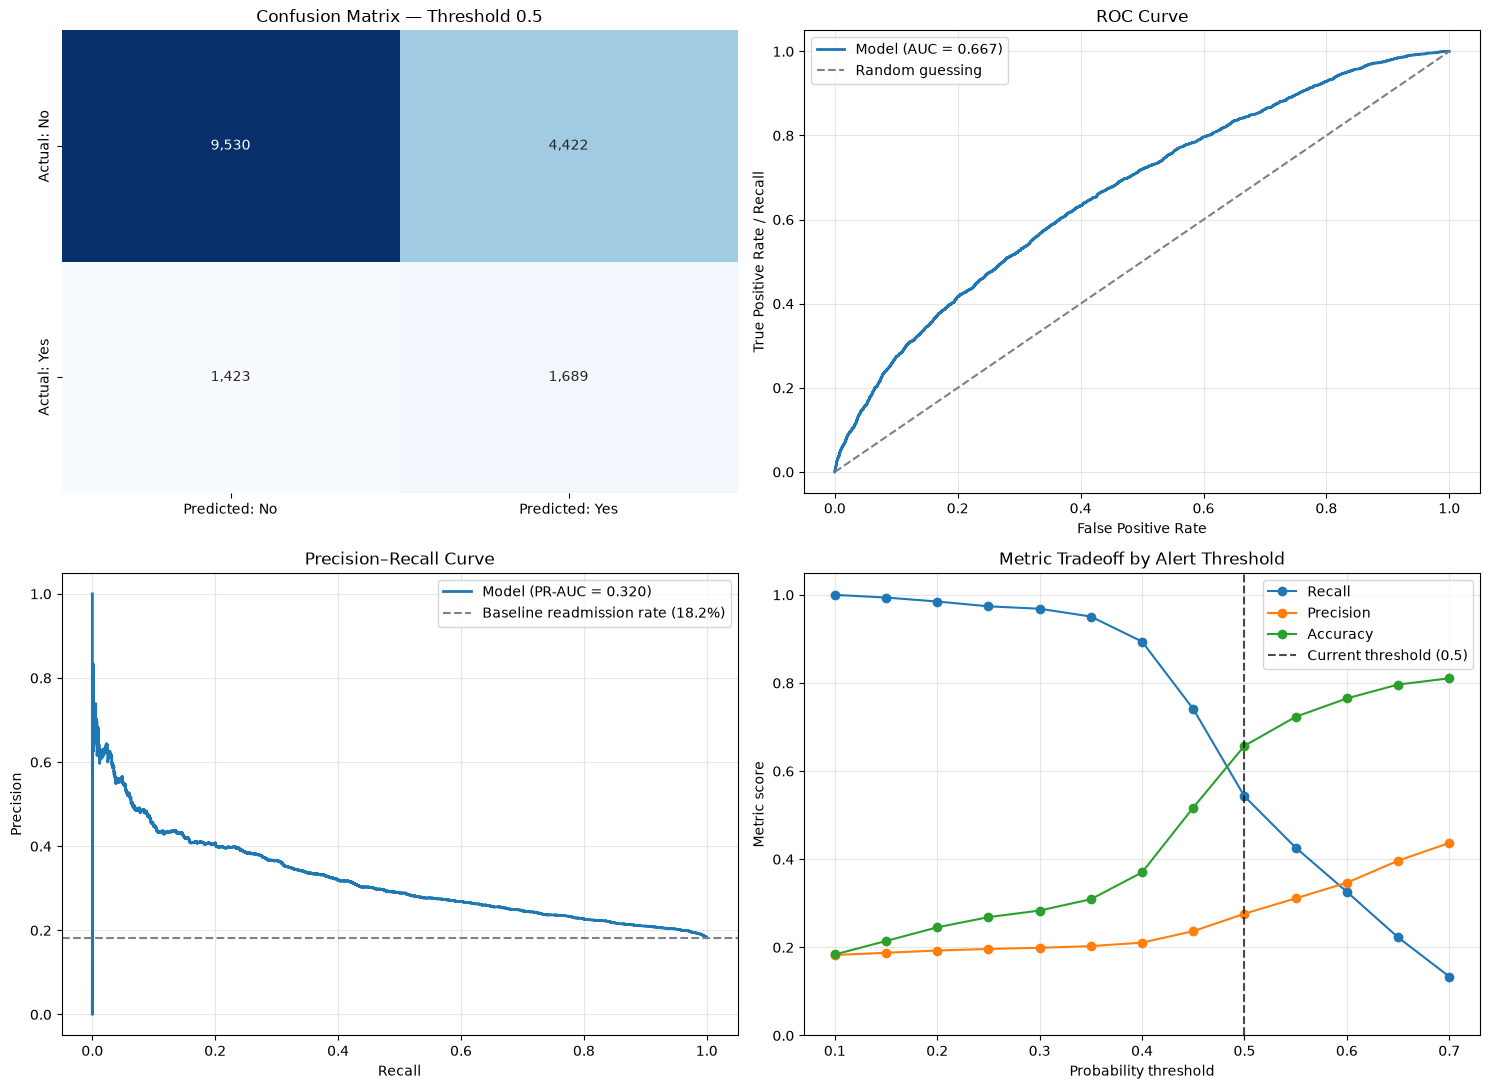

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)

# Predicted probability of readmission = 1
y_pred_proba = readmit_pipeline.predict_proba(X_test)[:, 1]

# Start by evaluating the usual 0.50 cutoff
threshold = 0.50
y_pred = (y_pred_proba >= threshold).astype(int)

# ----- Metrics -----
metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
    "PR-AUC": average_precision_score(y_test, y_pred_proba),
}

print(f"Metrics at threshold = {threshold}\n")

for name, value in metrics.items():
    print(f"{name:<10}: {value:.3f}")

# ----- Values used by plots -----
cm = confusion_matrix(y_test, y_pred)

fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(
    y_test,
    y_pred_proba,
)

# Test several possible alert thresholds
threshold_values = np.arange(0.10, 0.71, 0.05)

threshold_results = []

for t in threshold_values:
    predictions_at_t = (y_pred_proba >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "recall": recall_score(y_test, predictions_at_t, zero_division=0),
        "precision": precision_score(y_test, predictions_at_t, zero_division=0),
        "accuracy": accuracy_score(y_test, predictions_at_t),
        "f1": f1_score(y_test, predictions_at_t, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_results)

display(threshold_results.round(3))

# ----- Plots -----
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. Confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)
axes[0, 0].set_title(f"Confusion Matrix — Threshold {threshold}")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

# 2. ROC curve
axes[0, 1].plot(fpr, tpr, linewidth=2, label=f"Model (AUC = {metrics['ROC-AUC']:.3f})")
axes[0, 1].plot([0, 1], [0, 1], "--", color="gray", label="Random guessing")
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate / Recall")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Precision-recall curve
baseline_rate = y_test.mean()

axes[1, 0].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Model (PR-AUC = {metrics['PR-AUC']:.3f})",
)
axes[1, 0].axhline(
    baseline_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline readmission rate ({baseline_rate:.1%})",
)
axes[1, 0].set_title("Precision–Recall Curve")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Threshold tradeoff
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    marker="o",
    label="Accuracy",
)
axes[1, 1].axvline(
    threshold,
    linestyle="--",
    color="black",
    alpha=0.7,
    label=f"Current threshold ({threshold})",
)
axes[1, 1].set_title("Metric Tradeoff by Alert Threshold")
axes[1, 1].set_xlabel("Probability threshold")
axes[1, 1].set_ylabel("Metric score")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
chosen_threshold = 0.45

y_pred_recall_first = (
    y_pred_proba >= chosen_threshold
).astype(int)

In [31]:
# ==========================================================
# Leakage-free prior-admission history features
# Requires: admissions and readmit_cohort already exist
# ==========================================================

import pandas as pd

# 1. Put each patient's admissions in chronological order
admissions = admissions.sort_values(
    ["subject_id", "admittime"]
).reset_index(drop=True)

# 2. Calculate each admission's hospital LOS.
# We will ONLY use the PREVIOUS admission's LOS as a feature.
admissions["current_hosp_los_days"] = (
    admissions["dischtime"] - admissions["admittime"]
).dt.total_seconds() / (60 * 60 * 24)

# 3. Group admissions by patient
by_patient = admissions.groupby("subject_id")

# Number of admissions BEFORE the current admission
admissions["prior_admission_count"] = by_patient.cumcount()

# Previous admission's discharge time
admissions["previous_dischtime"] = by_patient["dischtime"].shift(1)

# Previous admission's hospital length of stay
admissions["previous_hospital_los_days"] = (
    by_patient["current_hosp_los_days"].shift(1)
)

# Days between previous discharge and current admission
admissions["days_since_prior_discharge"] = (
    admissions["admittime"] - admissions["previous_dischtime"]
).dt.total_seconds() / (60 * 60 * 24)

# 4. Keep only the columns we want to add to the ICU cohort
history_features = admissions[
    [
        "subject_id",
        "hadm_id",
        "prior_admission_count",
        "previous_hospital_los_days",
        "days_since_prior_discharge",
    ]
].copy()

# 5. Remove old versions of these columns, including _x / _y duplicates
history_names = [
    "prior_admission_count",
    "previous_hospital_los_days",
    "days_since_prior_discharge",
]

old_history_columns = [
    column
    for column in readmit_cohort.columns
    if column in history_names
    or any(column.startswith(f"{name}_") for name in history_names)
]

readmit_cohort = readmit_cohort.drop(
    columns=old_history_columns,
    errors="ignore",
)

# 6. Add one clean copy of each history feature
readmit_cohort = readmit_cohort.merge(
    history_features,
    on=["subject_id", "hadm_id"],
    how="left",
    validate="one_to_one",
)

# 7. Confirm it worked
print("New feature columns added successfully:\n")

print(
    readmit_cohort[
        [
            "subject_id",
            "hadm_id",
            "prior_admission_count",
            "previous_hospital_los_days",
            "days_since_prior_discharge",
            "readmit_30d",
        ]
    ].head(10)
)

New feature columns added successfully:

   subject_id   hadm_id  prior_admission_count  previous_hospital_los_days  \
0    14046553  20000094                      1                    0.983333   
1    14990224  20000147                      0                         NaN   
2    17913090  20000351                      9                    4.622917   
3    16788749  20000808                      0                         NaN   
4    15583900  20000916                      3                    1.152083   
5    16003661  20001305                     14                    2.361806   
6    14577567  20001361                      0                         NaN   
7    16679562  20001395                      7                    3.890278   
8    15975141  20001494                      1                    2.109722   
9    10117812  20001770                      0                         NaN   

   days_since_prior_discharge  readmit_30d  
0                 1540.500000            0  
1         

In [35]:
import pandas as pd

# Reset the display settings that affect dataframe rendering
pd.reset_option("display.max_colwidth")
pd.reset_option("display.float_format")
pd.reset_option("display.max_rows")
pd.reset_option("display.max_columns")

# Use reasonable display limits
pd.set_option("display.max_colwidth", 80)
pd.set_option("display.max_rows", 20)
pd.set_option("display.max_columns", 20)

In [36]:
readmit_cohort.head()

,subject_id,hadm_id,stay_id,first_careunit,last_careunit,intime,outtime,los,readmit_30d,days_to_next_admission,...,anchor_age,admission_type,admission_location,insurance,language,marital_status,race,prior_admission_count,previous_hospital_los_days,days_since_prior_discharge
0,14046553,20000094,35605481,Coronary Care Unit (CCU),Coronary Care Unit (CCU),2150-03-02 15:19:31,2150-03-03 11:28:38,0.839664,0,NaN,...,79,URGENT,TRANSFER FROM HOSPITAL,Medicare,English,WIDOWED,WHITE,1,0.983333,1540.500000
1,14990224,20000147,30503572,Cardiac Vascular Intensive Care Unit (CVICU),Cardiac Vascular Intensive Care Unit (CVICU),2121-08-30 16:33:54,2121-08-31 21:29:49,1.205498,0,788.34375,...,71,URGENT,TRANSFER FROM HOSPITAL,Medicare,English,MARRIED,WHITE - OTHER EUROPEAN,0,NaN,NaN
2,17913090,20000351,30593599,Medical/Surgical Intensive Care Unit (MICU/SICU),Medical/Surgical Intensive Care Unit (MICU/SICU),2145-06-13 20:10:27,2145-06-14 16:49:38,0.860544,0,NaN,...,42,OBSERVATION ADMIT,EMERGENCY ROOM,Medicaid,English,MARRIED,BLACK/AFRICAN AMERICAN,9,4.622917,177.342361
3,16788749,20000808,35191063,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2180-01-12 22:07:00,2180-01-13 13:36:47,0.645683,0,NaN,...,54,EW EMER.,EMERGENCY ROOM,Private,English,SINGLE,WHITE,0,NaN,NaN
4,15583900,20000916,39464752,Surgical Intensive Care Unit (SICU),Surgical Intensive Care Unit (SICU),2162-08-13 03:26:53,2162-08-13 20:54:23,0.727431,0,NaN,...,81,EW EMER.,TRANSFER FROM HOSPITAL,Medicare,English,MARRIED,WHITE,3,1.152083,1802.595833


In [37]:
for number, column in enumerate(readmit_cohort.columns, start=1):
    print(f"{number}. {column}")

1. subject_id
2. hadm_id
3. stay_id
4. first_careunit
5. last_careunit
6. intime
7. outtime
8. los
9. readmit_30d
10. days_to_next_admission
11. admittime
12. dischtime
13. days_since_previous_discharge
14. mean_prior_hospital_los_days
15. prior_icu_admission_count
16. prior_icu_stay_count
17. gender
18. anchor_age
19. admission_type
20. admission_location
21. insurance
22. language
23. marital_status
24. race
25. prior_admission_count
26. previous_hospital_los_days
27. days_since_prior_discharge


In [38]:
for column, dtype in readmit_cohort.dtypes.items():
    print(f"{column}  -  {dtype}")

subject_id  -  int64
hadm_id  -  int64
stay_id  -  int64
first_careunit  -  str
last_careunit  -  str
intime  -  datetime64[us]
outtime  -  datetime64[us]
los  -  float64
readmit_30d  -  int64
days_to_next_admission  -  float64
admittime  -  datetime64[us]
dischtime  -  datetime64[us]
days_since_previous_discharge  -  float64
mean_prior_hospital_los_days  -  float64
prior_icu_admission_count  -  int64
prior_icu_stay_count  -  int64
gender  -  str
anchor_age  -  int64
admission_type  -  str
admission_location  -  str
insurance  -  str
language  -  str
marital_status  -  str
race  -  str
prior_admission_count  -  int64
previous_hospital_los_days  -  float64
days_since_prior_discharge  -  float64


In [39]:
feature_columns = [
    # Information known at/near ICU admission
    "first_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # Leakage-free prior history
    "days_since_previous_discharge",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
    "prior_admission_count",
    "previous_hospital_los_days",
]

X = readmit_cohort[feature_columns].copy()
y = readmit_cohort["readmit_30d"].copy()
groups = readmit_cohort["subject_id"].copy()

print("X shape:", X.shape)
print("Target shape:", y.shape)
print("\nFeatures used:")
print(X.columns.tolist())

X shape: (85242, 15)
Target shape: (85242,)

Features used:
['first_careunit', 'gender', 'anchor_age', 'admission_type', 'admission_location', 'insurance', 'language', 'marital_status', 'race', 'days_since_previous_discharge', 'mean_prior_hospital_los_days', 'prior_icu_admission_count', 'prior_icu_stay_count', 'prior_admission_count', 'previous_hospital_los_days']


Total rows: 85,242
Features: 15
Overall 30-day readmission rate: 18.09%

X_train shape: (68178, 15)
X_test shape:  (17064, 15)
Patients shared by train and test: 0

Training readmission rate:
readmit_30d
0    81.95
1    18.05
Name: proportion, dtype: float64

Test readmission rate:
readmit_30d
0    81.76
1    18.24
Name: proportion, dtype: float64

scale_pos_weight: 4.539
Model training complete.

Metrics at threshold = 0.5
Accuracy  : 0.657
Precision : 0.278
Recall    : 0.550
F1 score  : 0.369
ROC-AUC   : 0.667
PR-AUC    : 0.320

Threshold comparison:
 threshold  recall  precision  accuracy    f1
      0.10   1.000      0.183     0.184 0.309
      0.15   0.996      0.188     0.214 0.316
      0.20   0.985      0.193     0.245 0.322
      0.25   0.975      0.196     0.268 0.327
      0.30   0.967      0.199     0.284 0.330
      0.35   0.949      0.203     0.309 0.334
      0.40   0.892      0.211     0.372 0.341
      0.45   0.746      0.237     0.517 0.360
      0.50   0.550      0.2

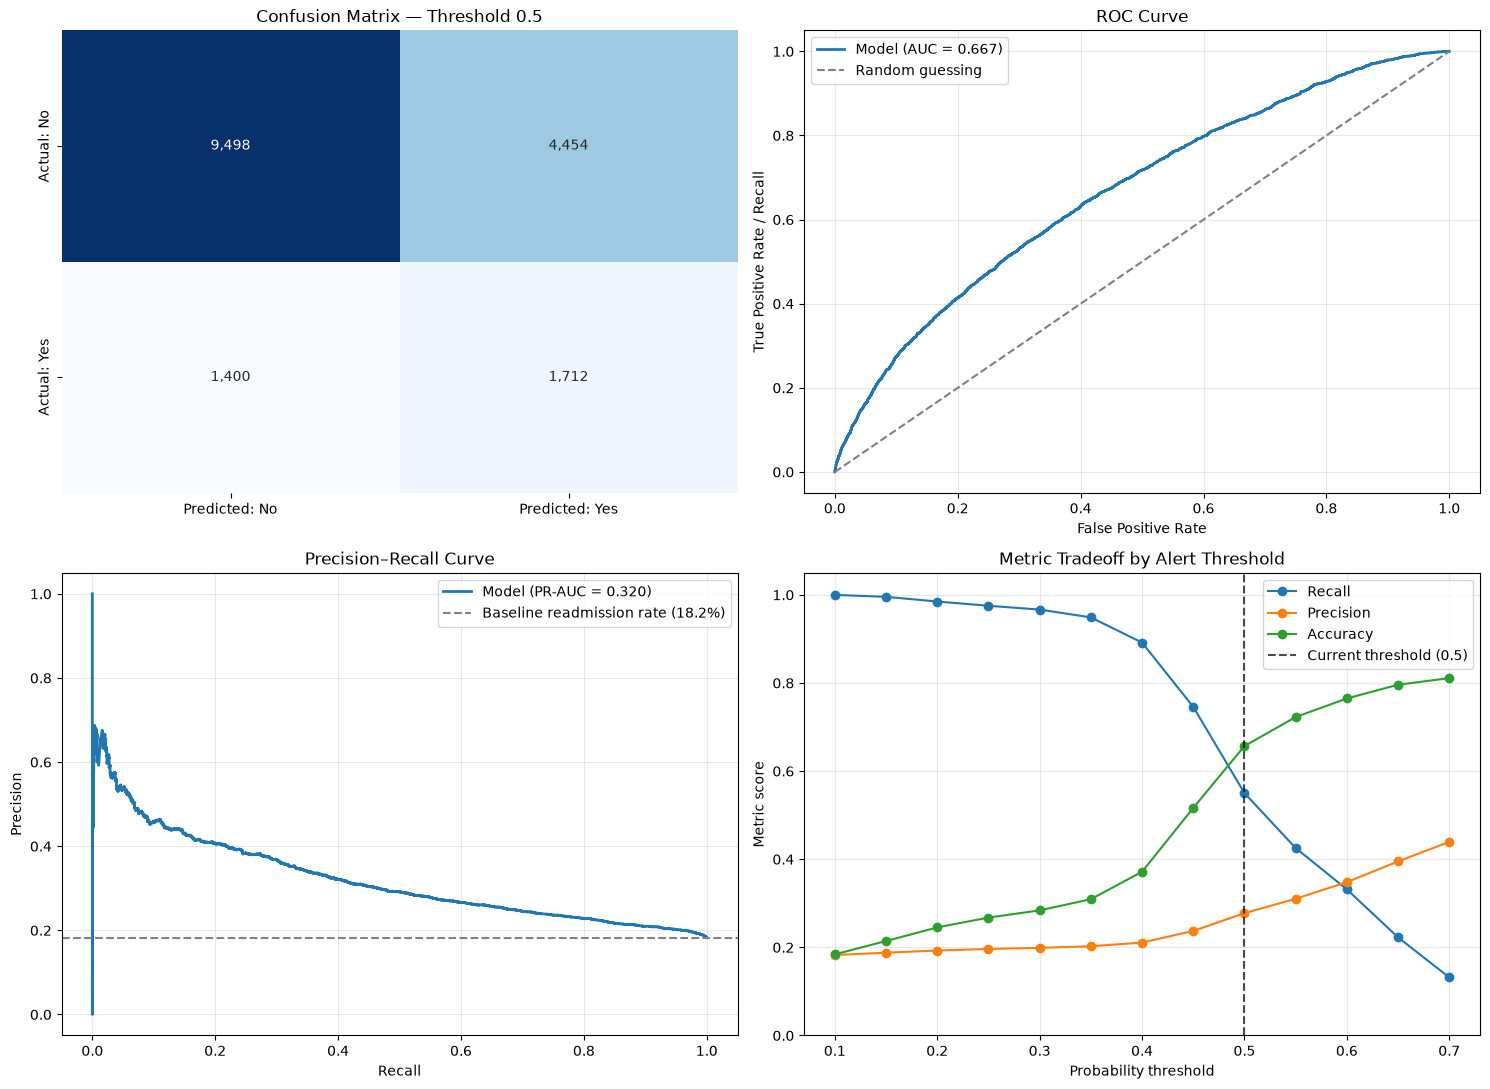

In [40]:
# ==========================================================
# Readmission model: split → preprocess → train → evaluate
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier


# ----------------------------------------------------------
# 1. Choose safe features and target
# ----------------------------------------------------------

feature_columns = [
    # Known at/near ICU admission
    "first_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # Leakage-free patient-history features
    "days_since_previous_discharge",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
    "prior_admission_count",
    "previous_hospital_los_days",
]

missing_columns = [
    column for column in feature_columns
    if column not in readmit_cohort.columns
]

if missing_columns:
    raise ValueError(f"Missing feature columns: {missing_columns}")

X = readmit_cohort[feature_columns].copy()
y = readmit_cohort["readmit_30d"].copy()
groups = readmit_cohort["subject_id"].copy()

print(f"Total rows: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"Overall 30-day readmission rate: {y.mean():.2%}")


# ----------------------------------------------------------
# 2. Patient-safe train/test split
# ----------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

train_patients = set(groups.iloc[train_index])
test_patients = set(groups.iloc[test_index])

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Patients shared by train and test: {len(train_patients & test_patients)}")

print("\nTraining readmission rate:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest readmission rate:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


# ----------------------------------------------------------
# 3. Preprocess: fill missing values and encode text columns
# ----------------------------------------------------------

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_train.columns.difference(
    categorical_features
).tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
)


# ----------------------------------------------------------
# 4. Train XGBoost with extra weight on readmissions
# ----------------------------------------------------------

number_of_zeros = (y_train == 0).sum()
number_of_ones = (y_train == 1).sum()

scale_pos_weight = number_of_zeros / number_of_ones

print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

readmit_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

readmit_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", readmit_model),
])

readmit_pipeline.fit(X_train, y_train)

print("Model training complete.")


# ----------------------------------------------------------
# 5. Predict and calculate metrics at threshold = 0.50
# ----------------------------------------------------------

y_pred_proba = readmit_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.50
y_pred = (y_pred_proba >= threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
    "PR-AUC": average_precision_score(y_test, y_pred_proba),
}

print(f"\nMetrics at threshold = {threshold}")

for name, value in metrics.items():
    print(f"{name:<10}: {value:.3f}")


# ----------------------------------------------------------
# 6. Compare recall / precision across alert thresholds
# ----------------------------------------------------------

threshold_values = np.arange(0.10, 0.71, 0.05)
threshold_results = []

for t in threshold_values:
    predicted_at_t = (y_pred_proba >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "recall": recall_score(y_test, predicted_at_t, zero_division=0),
        "precision": precision_score(y_test, predicted_at_t, zero_division=0),
        "accuracy": accuracy_score(y_test, predicted_at_t),
        "f1": f1_score(y_test, predicted_at_t, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_results)

print("\nThreshold comparison:")
print(threshold_results.round(3).to_string(index=False))


# ----------------------------------------------------------
# 7. Plot model performance
# ----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_proba,
)

baseline_readmission_rate = y_test.mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)
axes[0, 0].set_title(f"Confusion Matrix — Threshold {threshold}")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

# ROC curve
axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Model (AUC = {metrics['ROC-AUC']:.3f})",
)
axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random guessing",
)
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate / Recall")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision-recall curve
axes[1, 0].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Model (PR-AUC = {metrics['PR-AUC']:.3f})",
)
axes[1, 0].axhline(
    baseline_readmission_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline readmission rate ({baseline_readmission_rate:.1%})",
)
axes[1, 0].set_title("Precision–Recall Curve")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Threshold tradeoff
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    marker="o",
    label="Accuracy",
)
axes[1, 1].axvline(
    threshold,
    linestyle="--",
    color="black",
    alpha=0.7,
    label=f"Current threshold ({threshold})",
)
axes[1, 1].set_title("Metric Tradeoff by Alert Threshold")
axes[1, 1].set_xlabel("Probability threshold")
axes[1, 1].set_ylabel("Metric score")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

                                                                    feature  importance
                                                  categorical__race_UNKNOWN    0.105395
                                             numeric__prior_admission_count    0.071604
                                                    categorical__race_WHITE    0.028903
                                         categorical__race_UNABLE TO OBTAIN    0.028339
                                     numeric__days_since_previous_discharge    0.023842
                                        categorical__marital_status_MARRIED    0.018036
                                                      categorical__gender_M    0.016880
                                              categorical__language_English    0.014441
                                   categorical__admission_type_DIRECT EMER.    0.014348
                             categorical__first_careunit_Neuro Intermediate    0.013813
            categorical__first_c

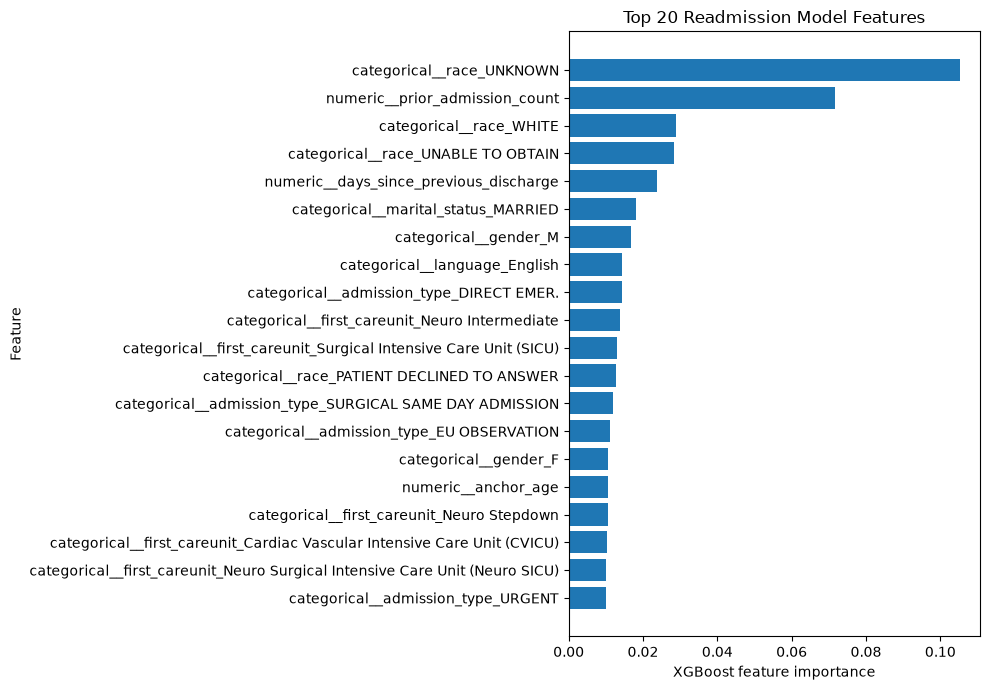

In [41]:
# Get the final feature names after one-hot encoding
final_feature_names = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Get XGBoost's importance score for each final feature
feature_importance = pd.DataFrame({
    "feature": final_feature_names,
    "importance": (
        readmit_pipeline
        .named_steps["model"]
        .feature_importances_
    ),
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False,
)

print(feature_importance.head(20).to_string(index=False))

plt.figure(figsize=(10, 7))

top_features = feature_importance.head(20).sort_values("importance")

plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 20 Readmission Model Features")
plt.xlabel("XGBoost feature importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

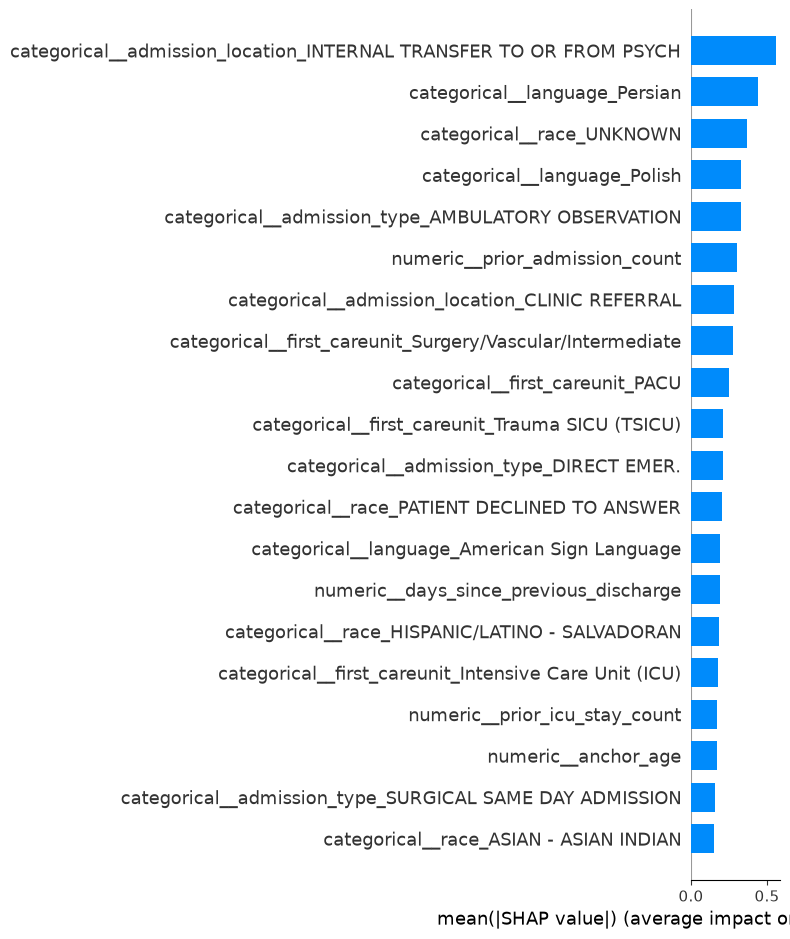

In [42]:
import shap

# Explain a random sample so SHAP stays reasonably fast
X_explain = X_test.sample(n=2000, random_state=42)

# Apply the SAME trained preprocessing steps used by the model
X_explain_encoded = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .transform(X_explain)
)

# Get the names of the 0/1 encoded features
encoded_feature_names = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Convert to a readable dataframe for SHAP
if hasattr(X_explain_encoded, "toarray"):
    X_explain_encoded = X_explain_encoded.toarray()

X_explain_encoded = pd.DataFrame(
    X_explain_encoded,
    columns=encoded_feature_names,
    index=X_explain.index,
)

# Pull out the trained XGBoost model
trained_xgb_model = readmit_pipeline.named_steps["model"]

# Calculate SHAP values
explainer = shap.TreeExplainer(trained_xgb_model)
shap_values = explainer.shap_values(X_explain_encoded)

# Compatibility with some older SHAP versions
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# 1. Global feature importance, based on average SHAP impact
shap.summary_plot(
    shap_values,
    X_explain_encoded,
    plot_type="bar",
    max_display=20,
)

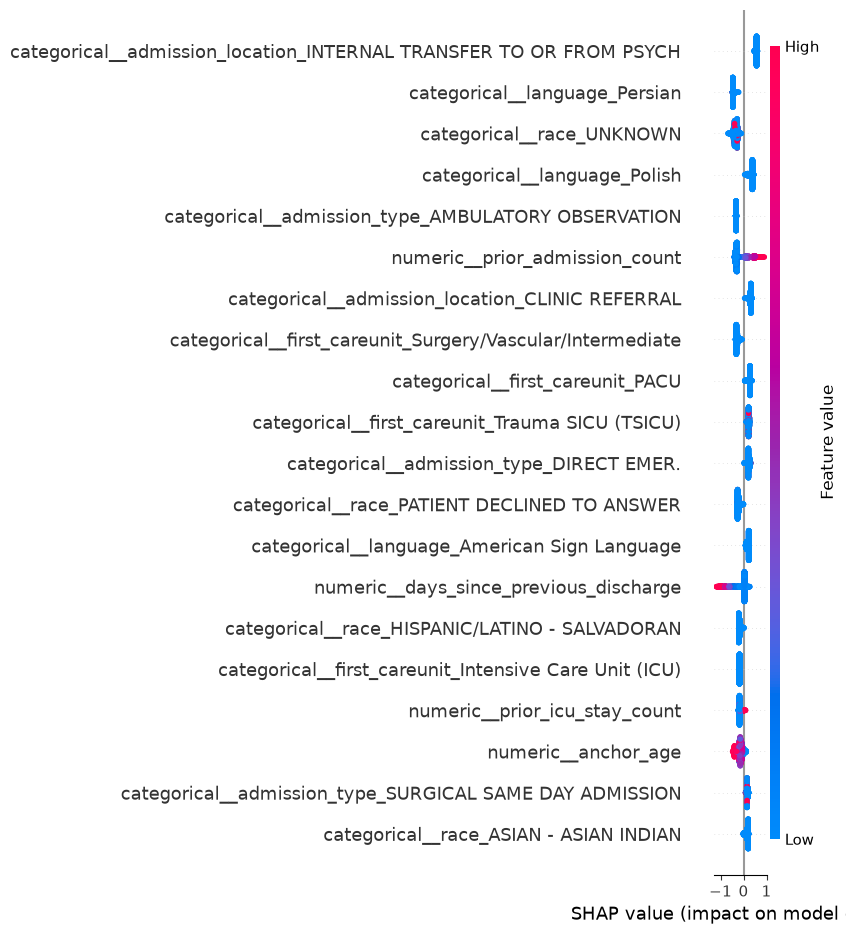

In [47]:
# 2. Direction + distribution of feature effects
shap.summary_plot(
    shap_values,
    X_explain_encoded,
    max_display=20,
)

In [48]:
# ==========================================================
# Build and merge first-24-hour ICU vital-sign features
# ==========================================================

from pathlib import Path
import pandas as pd

MIMIC_ROOT = Path(
    r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1"
)

chartevents_path = next(
    (MIMIC_ROOT / "icu").glob("chartevents.csv*")
)

# Vital-sign ITEMIDs from MIMIC-IV
vital_item_labels = {
    220045: "heart_rate",
    220210: "resp_rate",
    220277: "spo2",
    220179: "sbp_noninvasive",
    220180: "dbp_noninvasive",
    220181: "map_noninvasive",
    220739: "temperature",
    220621: "fio2",
    223835: "gcs_total",
}

# One row per ICU stay: its first-24-hour time window
icu_windows = readmit_cohort[
    ["stay_id", "intime"]
].drop_duplicates("stay_id").copy()

icu_windows["first_24h_end"] = (
    icu_windows["intime"] + pd.Timedelta(hours=24)
)

chunk_summaries = []

print(f"Reading: {chartevents_path.name}")

reader = pd.read_csv(
    chartevents_path,
    usecols=["stay_id", "itemid", "charttime", "valuenum"],
    parse_dates=["charttime"],
    chunksize=1_000_000,
)

for chunk_number, chunk in enumerate(reader, start=1):

    # Keep only the vital signs we care about
    chunk = chunk[
        chunk["itemid"].isin(vital_item_labels)
        & chunk["valuenum"].notna()
    ]

    if chunk.empty:
        continue

    # Add each ICU stay's first-24-hour window
    chunk = chunk.merge(
        icu_windows,
        on="stay_id",
        how="inner",
        validate="many_to_one",
    )

    # Strictly keep values observed during the first 24 ICU hours
    chunk = chunk[
        (chunk["charttime"] >= chunk["intime"])
        & (chunk["charttime"] < chunk["first_24h_end"])
    ]

    if chunk.empty:
        continue

    # Summarize this chunk by ICU stay and vital-sign type
    chunk_summary = (
        chunk.groupby(["stay_id", "itemid"])["valuenum"]
        .agg(
            event_count="count",
            value_sum="sum",
            vital_min="min",
            vital_max="max",
        )
        .reset_index()
    )

    chunk_summaries.append(chunk_summary)

    if chunk_number % 20 == 0:
        print(
            f"Processed {chunk_number:,} chunks "
            f"| kept {len(chunk_summaries):,} non-empty summaries"
        )

print("Finished reading chartevents.")

Reading: chartevents.csv.gz
Processed 20 chunks | kept 20 non-empty summaries
Processed 40 chunks | kept 40 non-empty summaries
Processed 60 chunks | kept 60 non-empty summaries
Processed 80 chunks | kept 80 non-empty summaries
Processed 100 chunks | kept 100 non-empty summaries
Processed 120 chunks | kept 120 non-empty summaries
Processed 140 chunks | kept 140 non-empty summaries
Processed 160 chunks | kept 160 non-empty summaries
Processed 180 chunks | kept 180 non-empty summaries
Processed 200 chunks | kept 200 non-empty summaries
Processed 220 chunks | kept 220 non-empty summaries
Processed 240 chunks | kept 240 non-empty summaries
Processed 260 chunks | kept 260 non-empty summaries
Processed 280 chunks | kept 280 non-empty summaries
Processed 300 chunks | kept 300 non-empty summaries
Processed 320 chunks | kept 320 non-empty summaries
Processed 340 chunks | kept 340 non-empty summaries
Processed 360 chunks | kept 360 non-empty summaries
Processed 380 chunks | kept 380 non-empty su

In [49]:
# ==========================================================
# Finalize vital features and merge them into readmit_cohort
# ==========================================================

if not chunk_summaries:
    raise ValueError("No first-24-hour vital-sign rows were found.")

# Combine partial summaries from every chunk
vital_long = pd.concat(chunk_summaries, ignore_index=True)

vital_long = (
    vital_long
    .groupby(["stay_id", "itemid"])
    .agg(
        event_count=("event_count", "sum"),
        value_sum=("value_sum", "sum"),
        vital_min=("vital_min", "min"),
        vital_max=("vital_max", "max"),
    )
    .reset_index()
)

# Mean = total values / total measurements
vital_long["vital_mean"] = (
    vital_long["value_sum"] / vital_long["event_count"]
)

# Give ITEMIDs readable names
vital_long["vital_name"] = vital_long["itemid"].map(vital_item_labels)

# Turn long event data into one row per ICU stay
vital_feature_frames = []

for metric in ["vital_mean", "vital_min", "vital_max", "event_count"]:
    wide_metric = vital_long.pivot(
        index="stay_id",
        columns="vital_name",
        values=metric,
    )

    wide_metric.columns = [
        f"{vital}_{metric}"
        for vital in wide_metric.columns
    ]

    vital_feature_frames.append(wide_metric)

vital_features = pd.concat(vital_feature_frames, axis=1).reset_index()

vital_feature_columns = [
    column
    for column in vital_features.columns
    if column != "stay_id"
]

# Safe to rerun: remove old versions of these features first
old_vital_columns = [
    column
    for column in readmit_cohort.columns
    if column in vital_feature_columns
    or any(column.startswith(f"{name}_") for name in vital_feature_columns)
]

readmit_cohort = readmit_cohort.drop(
    columns=old_vital_columns,
    errors="ignore",
)

# Add one row of vital summaries to each ICU stay
readmit_cohort = readmit_cohort.merge(
    vital_features,
    on="stay_id",
    how="left",
    validate="one_to_one",
)

print(f"Vital features created: {len(vital_feature_columns)}")
print(f"New readmit_cohort shape: {readmit_cohort.shape}")

print("\nExample vital features:")
print(vital_feature_columns[:12])

print("\nCoverage of first-24-hour heart-rate mean:")
print(
    readmit_cohort["heart_rate_vital_mean"]
    .notna()
    .mean()
    .mul(100)
    .round(2),
    "%"
)

Vital features created: 36
New readmit_cohort shape: (85242, 63)

Example vital features:
['dbp_noninvasive_vital_mean', 'fio2_vital_mean', 'gcs_total_vital_mean', 'heart_rate_vital_mean', 'map_noninvasive_vital_mean', 'resp_rate_vital_mean', 'sbp_noninvasive_vital_mean', 'spo2_vital_mean', 'temperature_vital_mean', 'dbp_noninvasive_vital_min', 'fio2_vital_min', 'gcs_total_vital_min']

Coverage of first-24-hour heart-rate mean:


AttributeError: 'numpy.float64' object has no attribute 'mul'

In [50]:
heart_rate_coverage = (
    readmit_cohort["heart_rate_vital_mean"]
    .notna()
    .mean()
    * 100
)

print(f"Coverage of first-24-hour heart-rate mean: {heart_rate_coverage:.2f}%")

Coverage of first-24-hour heart-rate mean: 99.89%


Total rows: 85,242
Features: 51
Overall 30-day readmission rate: 18.09%

X_train shape: (68178, 51)
X_test shape:  (17064, 51)
Patients shared by train and test: 0

Training readmission rate:
readmit_30d
0    81.95
1    18.05
Name: proportion, dtype: float64

Test readmission rate:
readmit_30d
0    81.76
1    18.24
Name: proportion, dtype: float64

scale_pos_weight: 4.539
Model training complete.

Metrics at threshold = 0.5
Accuracy  : 0.647
Precision : 0.278
Recall    : 0.585
F1 score  : 0.377
ROC-AUC   : 0.676
PR-AUC    : 0.331

Threshold comparison:
 threshold  recall  precision  accuracy    f1
      0.10   0.997      0.185     0.197 0.312
      0.15   0.992      0.188     0.218 0.316
      0.20   0.982      0.194     0.253 0.324
      0.25   0.972      0.199     0.282 0.331
      0.30   0.957      0.203     0.305 0.334
      0.35   0.931      0.209     0.343 0.341
      0.40   0.863      0.220     0.416 0.350
      0.45   0.738      0.243     0.532 0.365
      0.50   0.585      0.2

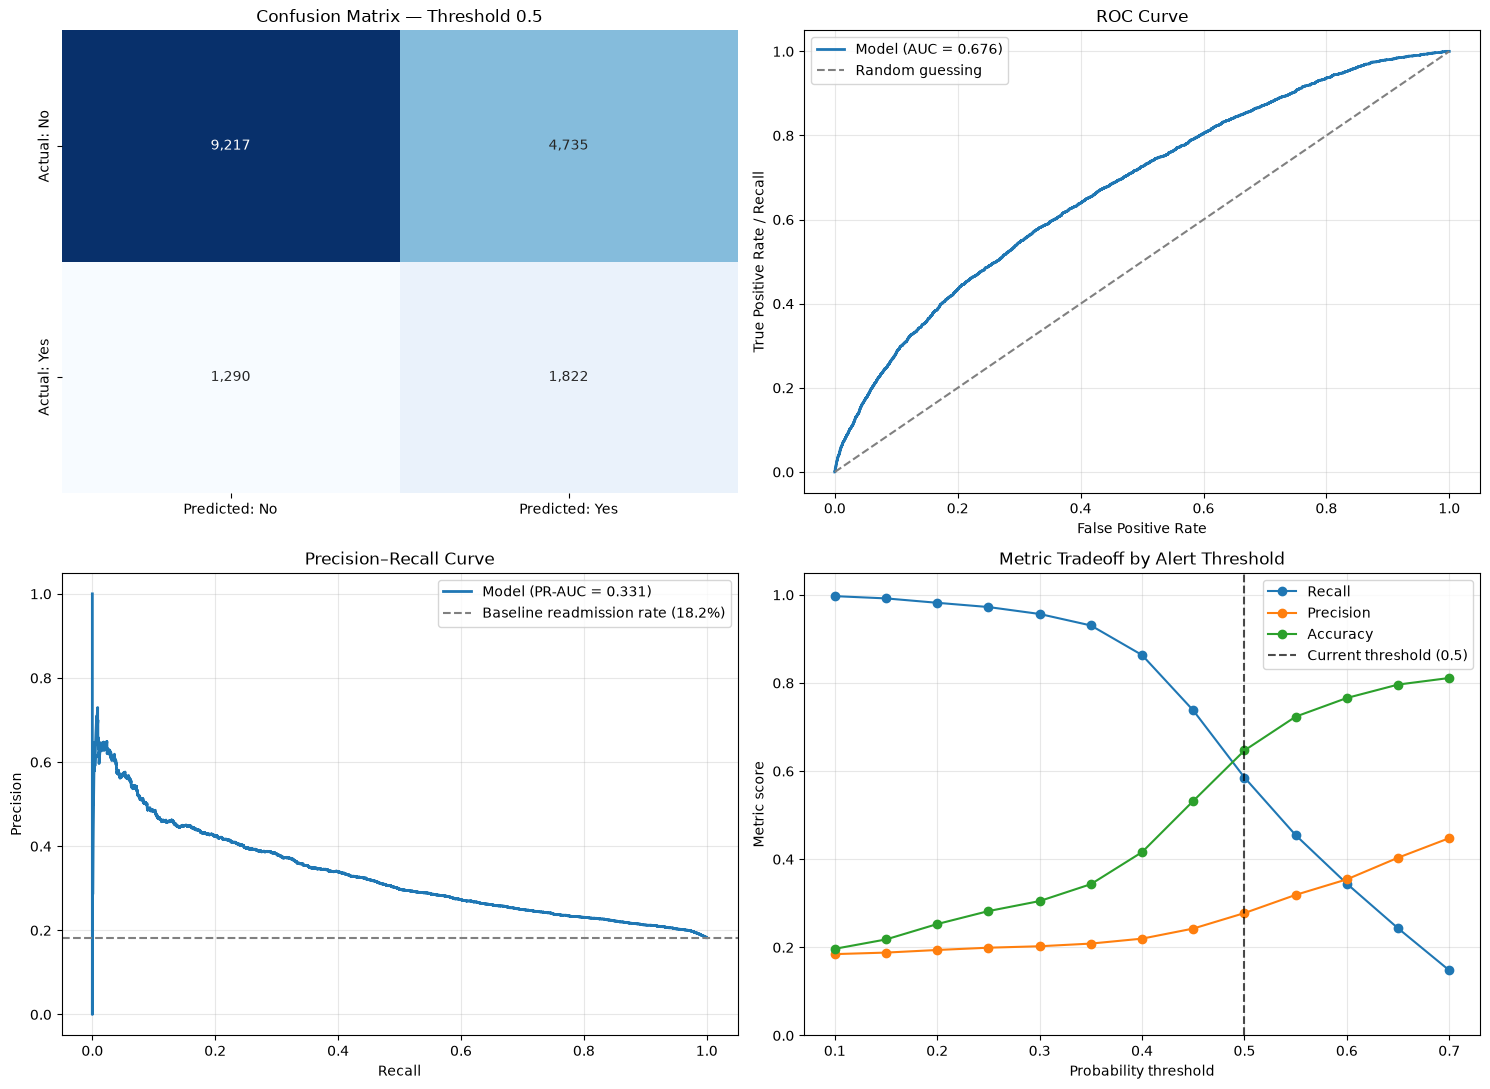

In [51]:
# ==========================================================
# Readmission model: split → preprocess → train → evaluate
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier


# ----------------------------------------------------------
# 1. Choose safe features and target
# ----------------------------------------------------------

feature_columns = [
    # Known at/near ICU admission
    "first_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # Leakage-free patient-history features
    "days_since_previous_discharge",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
    "prior_admission_count",
    "previous_hospital_los_days",

    # New first-24-hour vital-sign features
    *vital_feature_columns,
]




missing_columns = [
    column for column in feature_columns
    if column not in readmit_cohort.columns
]

if missing_columns:
    raise ValueError(f"Missing feature columns: {missing_columns}")

X = readmit_cohort[feature_columns].copy()
y = readmit_cohort["readmit_30d"].copy()
groups = readmit_cohort["subject_id"].copy()

print(f"Total rows: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"Overall 30-day readmission rate: {y.mean():.2%}")


# ----------------------------------------------------------
# 2. Patient-safe train/test split
# ----------------------------------------------------------

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

train_patients = set(groups.iloc[train_index])
test_patients = set(groups.iloc[test_index])

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"Patients shared by train and test: {len(train_patients & test_patients)}")

print("\nTraining readmission rate:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest readmission rate:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


# ----------------------------------------------------------
# 3. Preprocess: fill missing values and encode text columns
# ----------------------------------------------------------

categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_train.columns.difference(
    categorical_features
).tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
)


# ----------------------------------------------------------
# 4. Train XGBoost with extra weight on readmissions
# ----------------------------------------------------------

number_of_zeros = (y_train == 0).sum()
number_of_ones = (y_train == 1).sum()

scale_pos_weight = number_of_zeros / number_of_ones

print(f"\nscale_pos_weight: {scale_pos_weight:.3f}")

readmit_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

readmit_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", readmit_model),
])

readmit_pipeline.fit(X_train, y_train)

print("Model training complete.")


# ----------------------------------------------------------
# 5. Predict and calculate metrics at threshold = 0.50
# ----------------------------------------------------------

y_pred_proba = readmit_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.50
y_pred = (y_pred_proba >= threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
    "PR-AUC": average_precision_score(y_test, y_pred_proba),
}

print(f"\nMetrics at threshold = {threshold}")

for name, value in metrics.items():
    print(f"{name:<10}: {value:.3f}")


# ----------------------------------------------------------
# 6. Compare recall / precision across alert thresholds
# ----------------------------------------------------------

threshold_values = np.arange(0.10, 0.71, 0.05)
threshold_results = []

for t in threshold_values:
    predicted_at_t = (y_pred_proba >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "recall": recall_score(y_test, predicted_at_t, zero_division=0),
        "precision": precision_score(y_test, predicted_at_t, zero_division=0),
        "accuracy": accuracy_score(y_test, predicted_at_t),
        "f1": f1_score(y_test, predicted_at_t, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_results)

print("\nThreshold comparison:")
print(threshold_results.round(3).to_string(index=False))


# ----------------------------------------------------------
# 7. Plot model performance
# ----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_proba,
)

baseline_readmission_rate = y_test.mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)
axes[0, 0].set_title(f"Confusion Matrix — Threshold {threshold}")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

# ROC curve
axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Model (AUC = {metrics['ROC-AUC']:.3f})",
)
axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random guessing",
)
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate / Recall")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision-recall curve
axes[1, 0].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Model (PR-AUC = {metrics['PR-AUC']:.3f})",
)
axes[1, 0].axhline(
    baseline_readmission_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline readmission rate ({baseline_readmission_rate:.1%})",
)
axes[1, 0].set_title("Precision–Recall Curve")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Threshold tradeoff
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    marker="o",
    label="Accuracy",
)
axes[1, 1].axvline(
    threshold,
    linestyle="--",
    color="black",
    alpha=0.7,
    label=f"Current threshold ({threshold})",
)
axes[1, 1].set_title("Metric Tradeoff by Alert Threshold")
axes[1, 1].set_xlabel("Probability threshold")
axes[1, 1].set_ylabel("Metric score")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

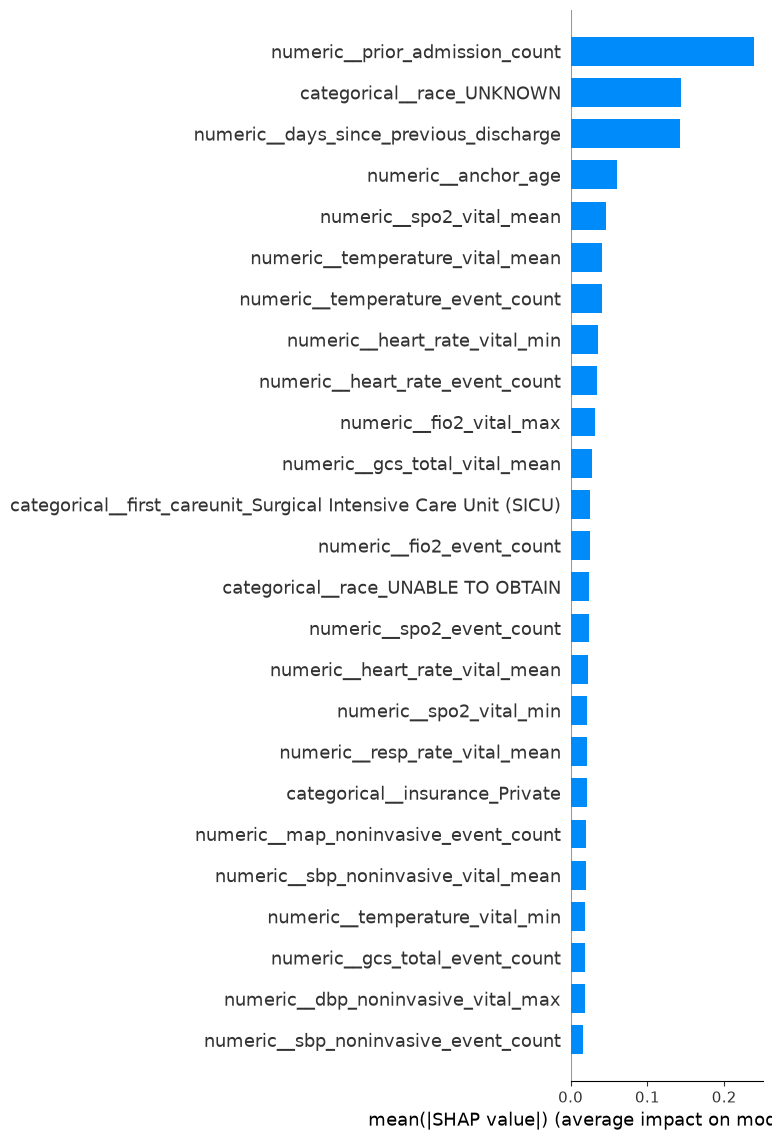

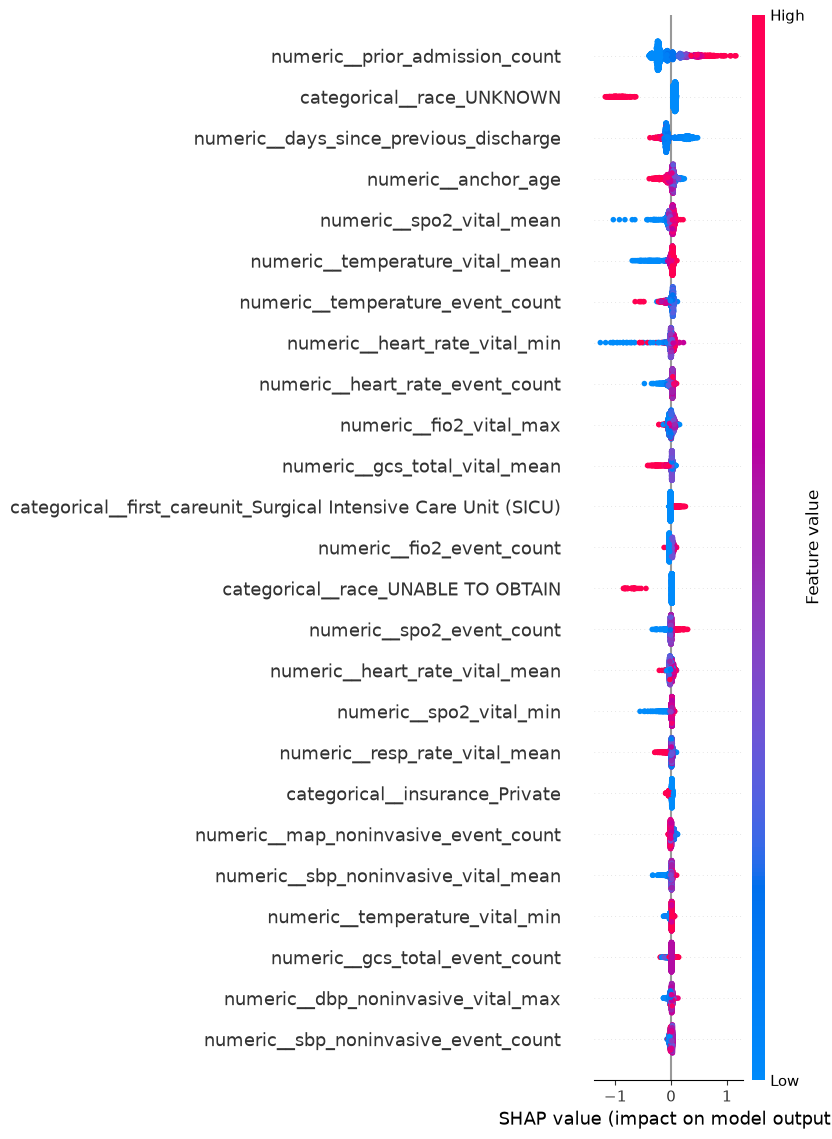

In [52]:
import shap

# Explain a random sample of the updated test data
X_explain = X_test.sample(n=2000, random_state=42)

# Apply the trained pipeline's preprocessing
X_explain_encoded = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .transform(X_explain)
)

encoded_feature_names = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Convert sparse encoded output into a dataframe SHAP can label clearly
if hasattr(X_explain_encoded, "toarray"):
    X_explain_encoded = X_explain_encoded.toarray()

X_explain_encoded = pd.DataFrame(
    X_explain_encoded,
    columns=encoded_feature_names,
    index=X_explain.index,
)

trained_xgb_model = readmit_pipeline.named_steps["model"]

explainer = shap.TreeExplainer(trained_xgb_model)
shap_values = explainer.shap_values(X_explain_encoded)

if isinstance(shap_values, list):
    shap_values = shap_values[1]

# Global ranking: which features matter most overall
shap.summary_plot(
    shap_values,
    X_explain_encoded,
    plot_type="bar",
    max_display=25,
)

# Direction: which feature values push risk higher or lower
shap.summary_plot(
    shap_values,
    X_explain_encoded,
    max_display=25,
)

In [55]:
readmit_cohort.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'first_careunit', 'last_careunit',
       'intime', 'outtime', 'los', 'readmit_30d', 'days_to_next_admission',
       'admittime', 'dischtime', 'days_since_previous_discharge',
       'mean_prior_hospital_los_days', 'prior_icu_admission_count',
       'prior_icu_stay_count', 'gender', 'anchor_age', 'admission_type',
       'admission_location', 'insurance', 'language', 'marital_status', 'race',
       'prior_admission_count', 'previous_hospital_los_days',
       'days_since_prior_discharge', 'dbp_noninvasive_vital_mean',
       'fio2_vital_mean', 'gcs_total_vital_mean', 'heart_rate_vital_mean',
       'map_noninvasive_vital_mean', 'resp_rate_vital_mean',
       'sbp_noninvasive_vital_mean', 'spo2_vital_mean',
       'temperature_vital_mean', 'dbp_noninvasive_vital_min', 'fio2_vital_min',
       'gcs_total_vital_min', 'heart_rate_vital_min',
       'map_noninvasive_vital_min', 'resp_rate_vital_min',
       'sbp_noninvasive_vital_min', 'spo2_vit

In [56]:
readmit_cohort.shape

(85242, 63)

In [57]:
from pathlib import Path
import pandas as pd

MIMIC_ROOT = Path(
    r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1"
)

labitems_path = next(
    (MIMIC_ROOT / "hosp").glob("d_labitems.csv*")
)

labitems = pd.read_csv(labitems_path)

lab_search_words = (
    "creatinine|urea nitrogen|white blood|hemoglobin|platelet|"
    "sodium|potassium|glucose|lactate|bilirubin|albumin"
)

important_labs = labitems[
    labitems["label"]
    .str.contains(lab_search_words, case=False, na=False)
].sort_values("label")

print(
    important_labs[
        ["itemid", "label", "fluid", "category"]
    ].to_string(index=False)
)

 itemid                             label               fluid   category
  50852                  % Hemoglobin A1c               Blood  Chemistry
  51775                         (Albumin) Cerebrospinal Fluid  Chemistry
  51807                         (Albumin)         Joint Fluid  Chemistry
  51910                         (Albumin)             Pleural  Chemistry
  51926                         (Albumin)               Stool  Chemistry
  53116                         (Albumin)             Ascites  Chemistry
  53138                         (Albumin)               Blood  Chemistry
  51067                  24 hr Creatinine               Urine  Chemistry
  51776                         <Albumin> Cerebrospinal Fluid  Chemistry
  51836                         <Albumin>    Other Body Fluid  Chemistry
  50855               Absolute Hemoglobin               Blood  Chemistry
  50862                           Albumin               Blood  Chemistry
  53085                           Albumin          

In [58]:
selected_labs = {
    50912: "creatinine",
    51006: "bun",
    51301: "wbc",
    51222: "hemoglobin",
    51265: "platelet_count",
    50983: "sodium",
    50971: "potassium",
    50931: "glucose",
    50813: "lactate",
    50885: "bilirubin_total",
    50862: "albumin",
}

In [59]:
# ==========================================================
# Read selected first-24-hour lab results in chunks
# ==========================================================

from pathlib import Path
import pandas as pd

MIMIC_ROOT = Path(
    r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1"
)

labevents_path = next(
    (MIMIC_ROOT / "hosp").glob("labevents.csv*")
)

# One ICU window per hospital admission
admission_windows = readmit_cohort[
    ["hadm_id", "intime"]
].drop_duplicates("hadm_id").copy()

admission_windows["first_24h_end"] = (
    admission_windows["intime"] + pd.Timedelta(hours=24)
)

lab_chunk_summaries = []

print(f"Reading: {labevents_path.name}")

reader = pd.read_csv(
    labevents_path,
    usecols=["hadm_id", "itemid", "charttime", "valuenum"],
    parse_dates=["charttime"],
    chunksize=1_000_000,
)

for chunk_number, chunk in enumerate(reader, start=1):

    # Keep only the lab tests we selected and actual numeric results
    chunk = chunk[
        chunk["itemid"].isin(selected_labs)
        & chunk["valuenum"].notna()
        & chunk["hadm_id"].notna()
    ].copy()

    if not chunk.empty:

        # hadm_id becomes float in labevents because some rows are missing it
        chunk["hadm_id"] = chunk["hadm_id"].astype("int64")

        # Attach the ICU first-24-hour window
        chunk = chunk.merge(
            admission_windows,
            on="hadm_id",
            how="inner",
            validate="many_to_one",
        )

        # Keep only labs measured within the first 24 ICU hours
        chunk = chunk[
            (chunk["charttime"] >= chunk["intime"])
            & (chunk["charttime"] < chunk["first_24h_end"])
        ]

        if not chunk.empty:

            chunk_summary = (
                chunk.groupby(["hadm_id", "itemid"])["valuenum"]
                .agg(
                    event_count="count",
                    value_sum="sum",
                    lab_min="min",
                    lab_max="max",
                )
                .reset_index()
            )

            lab_chunk_summaries.append(chunk_summary)

    if chunk_number % 20 == 0:
        print(
            f"Processed {chunk_number:,} chunks "
            f"| kept {len(lab_chunk_summaries):,} non-empty summaries"
        )

print("\nFinished reading labevents.")
print(f"Non-empty summaries collected: {len(lab_chunk_summaries):,}")

Reading: labevents.csv.gz
Processed 20 chunks | kept 20 non-empty summaries
Processed 40 chunks | kept 40 non-empty summaries
Processed 60 chunks | kept 60 non-empty summaries
Processed 80 chunks | kept 80 non-empty summaries
Processed 100 chunks | kept 100 non-empty summaries
Processed 120 chunks | kept 120 non-empty summaries
Processed 140 chunks | kept 140 non-empty summaries

Finished reading labevents.
Non-empty summaries collected: 159


In [60]:
# ==========================================================
# Finalize first-24-hour lab features and merge into cohort
# ==========================================================

if not lab_chunk_summaries:
    raise ValueError("No selected first-24-hour lab rows were found.")

# Stack all chunk-level summaries together
lab_long = pd.concat(
    lab_chunk_summaries,
    ignore_index=True,
)

# Combine summaries for the same admission + lab across chunks
lab_long = (
    lab_long
    .groupby(["hadm_id", "itemid"])
    .agg(
        event_count=("event_count", "sum"),
        value_sum=("value_sum", "sum"),
        lab_min=("lab_min", "min"),
        lab_max=("lab_max", "max"),
    )
    .reset_index()
)

# Calculate each selected lab's first-24-hour average
lab_long["lab_mean"] = (
    lab_long["value_sum"] / lab_long["event_count"]
)

# Change numeric lab IDs into readable names
lab_long["lab_name"] = lab_long["itemid"].map(selected_labs)

# Turn long lab rows into columns: one row per hospital admission
lab_feature_frames = []

for metric in ["lab_mean", "lab_min", "lab_max", "event_count"]:

    wide_metric = lab_long.pivot(
        index="hadm_id",
        columns="lab_name",
        values=metric,
    )

    wide_metric.columns = [
        f"{lab}_{metric}"
        for lab in wide_metric.columns
    ]

    lab_feature_frames.append(wide_metric)

lab_features = pd.concat(
    lab_feature_frames,
    axis=1,
).reset_index()

lab_feature_columns = [
    column
    for column in lab_features.columns
    if column != "hadm_id"
]

# Safe to rerun: remove any old lab-feature copies first
old_lab_columns = [
    column
    for column in readmit_cohort.columns
    if column in lab_feature_columns
    or any(column.startswith(f"{name}_") for name in lab_feature_columns)
]

readmit_cohort = readmit_cohort.drop(
    columns=old_lab_columns,
    errors="ignore",
)

# Each admission has at most one final lab-feature row
readmit_cohort = readmit_cohort.merge(
    lab_features,
    on="hadm_id",
    how="left",
    validate="many_to_one",
)

print(f"Lab features created: {len(lab_feature_columns)}")
print(f"New readmit_cohort shape: {readmit_cohort.shape}")

print("\nExample lab features:")
print(lab_feature_columns[:12])

creatinine_coverage = (
    readmit_cohort["creatinine_lab_mean"]
    .notna()
    .mean()
    * 100
)

print(
    f"\nCoverage of first-24-hour creatinine mean: "
    f"{creatinine_coverage:.2f}%"
)

Lab features created: 44
New readmit_cohort shape: (85242, 107)

Example lab features:
['albumin_lab_mean', 'bilirubin_total_lab_mean', 'bun_lab_mean', 'creatinine_lab_mean', 'glucose_lab_mean', 'hemoglobin_lab_mean', 'lactate_lab_mean', 'platelet_count_lab_mean', 'potassium_lab_mean', 'sodium_lab_mean', 'wbc_lab_mean', 'albumin_lab_min']

Coverage of first-24-hour creatinine mean: 96.85%


Total rows: 85,242
Features: 95
Overall 30-day readmission rate: 18.09%

X_train shape: (68178, 95)
X_test shape:  (17064, 95)
Patients shared by train and test: 0
scale_pos_weight: 4.539
Model training complete.

Metrics at threshold = 0.5
Accuracy  : 0.650
Precision : 0.282
Recall    : 0.594
F1 score  : 0.383
ROC-AUC   : 0.685
PR-AUC    : 0.334

Threshold comparison:
 threshold  recall  precision  accuracy    f1
      0.10   0.997      0.185     0.200 0.313
      0.15   0.992      0.189     0.220 0.317
      0.20   0.982      0.195     0.257 0.325
      0.25   0.971      0.199     0.284 0.331
      0.30   0.958      0.204     0.312 0.337
      0.35   0.927      0.210     0.352 0.343
      0.40   0.856      0.226     0.438 0.357
      0.45   0.738      0.253     0.556 0.377
      0.50   0.594      0.282     0.650 0.383
      0.55   0.458      0.320     0.723 0.377
      0.60   0.357      0.362     0.768 0.359
      0.65   0.251      0.408     0.797 0.311
      0.70   0.157      0.449 

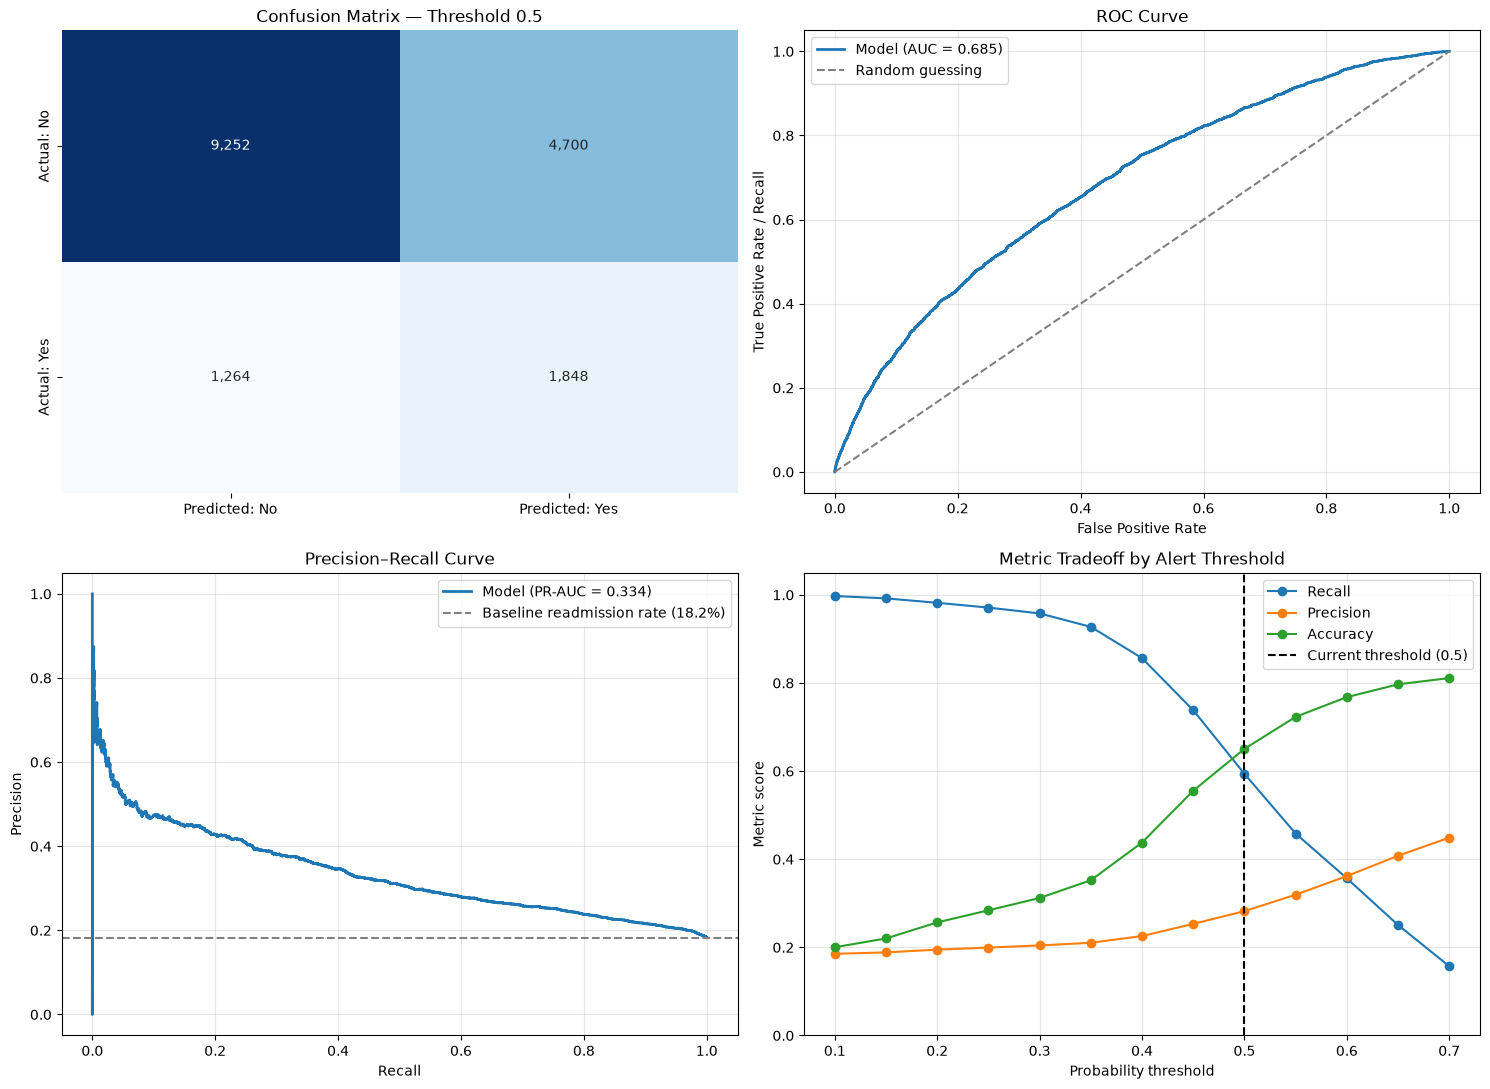

In [61]:
# ==========================================================
# Readmission model: vitals + labs + history
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier


# 1. Select safe features
feature_columns = [
    # Admission-time features
    "first_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # Prior-history features
    "days_since_previous_discharge",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
    "prior_admission_count",
    "previous_hospital_los_days",

    # First-24-hour vitals
    *vital_feature_columns,

    # First-24-hour labs
    *lab_feature_columns,
]

missing_columns = [
    column
    for column in feature_columns
    if column not in readmit_cohort.columns
]

if missing_columns:
    raise ValueError(f"Missing feature columns: {missing_columns}")

X = readmit_cohort[feature_columns].copy()
y = readmit_cohort["readmit_30d"].copy()
groups = readmit_cohort["subject_id"].copy()

print(f"Total rows: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"Overall 30-day readmission rate: {y.mean():.2%}")


# 2. Patient-safe split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

train_patients = set(groups.iloc[train_index])
test_patients = set(groups.iloc[test_index])

print(f"Patients shared by train and test: {len(train_patients & test_patients)}")


# 3. Preprocess numbers and text
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_train.columns.difference(
    categorical_features
).tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
)


# 4. Train XGBoost
number_of_zeros = (y_train == 0).sum()
number_of_ones = (y_train == 1).sum()

scale_pos_weight = number_of_zeros / number_of_ones

print(f"scale_pos_weight: {scale_pos_weight:.3f}")

readmit_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

readmit_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", readmit_model),
])

readmit_pipeline.fit(X_train, y_train)

print("Model training complete.")


# 5. Predictions and metrics
y_pred_proba = readmit_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.50
y_pred = (y_pred_proba >= threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
    "PR-AUC": average_precision_score(y_test, y_pred_proba),
}

print(f"\nMetrics at threshold = {threshold}")

for name, value in metrics.items():
    print(f"{name:<10}: {value:.3f}")


# 6. Threshold comparison
threshold_values = np.arange(0.10, 0.71, 0.05)
threshold_results = []

for t in threshold_values:
    predicted_at_t = (y_pred_proba >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "recall": recall_score(y_test, predicted_at_t, zero_division=0),
        "precision": precision_score(y_test, predicted_at_t, zero_division=0),
        "accuracy": accuracy_score(y_test, predicted_at_t),
        "f1": f1_score(y_test, predicted_at_t, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_results)

print("\nThreshold comparison:")
print(threshold_results.round(3).to_string(index=False))


# 7. Plots
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_proba,
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)
axes[0, 0].set_title(f"Confusion Matrix — Threshold {threshold}")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

# ROC curve
axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Model (AUC = {metrics['ROC-AUC']:.3f})",
)
axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random guessing",
)
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate / Recall")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision-recall curve
baseline_rate = y_test.mean()

axes[1, 0].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Model (PR-AUC = {metrics['PR-AUC']:.3f})",
)
axes[1, 0].axhline(
    baseline_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline readmission rate ({baseline_rate:.1%})",
)
axes[1, 0].set_title("Precision–Recall Curve")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Threshold tradeoff
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    marker="o",
    label="Accuracy",
)
axes[1, 1].axvline(
    threshold,
    linestyle="--",
    color="black",
    label=f"Current threshold ({threshold})",
)
axes[1, 1].set_title("Metric Tradeoff by Alert Threshold")
axes[1, 1].set_xlabel("Probability threshold")
axes[1, 1].set_ylabel("Metric score")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

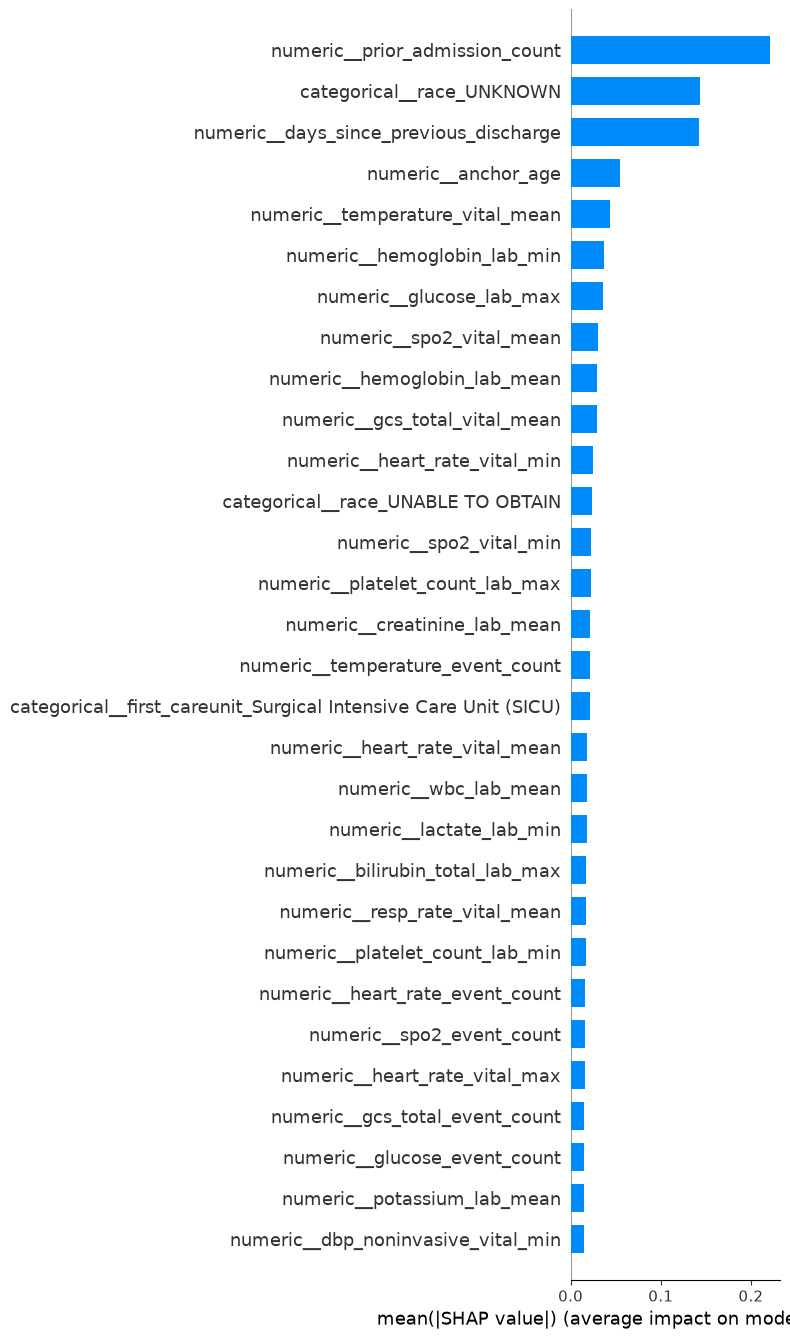

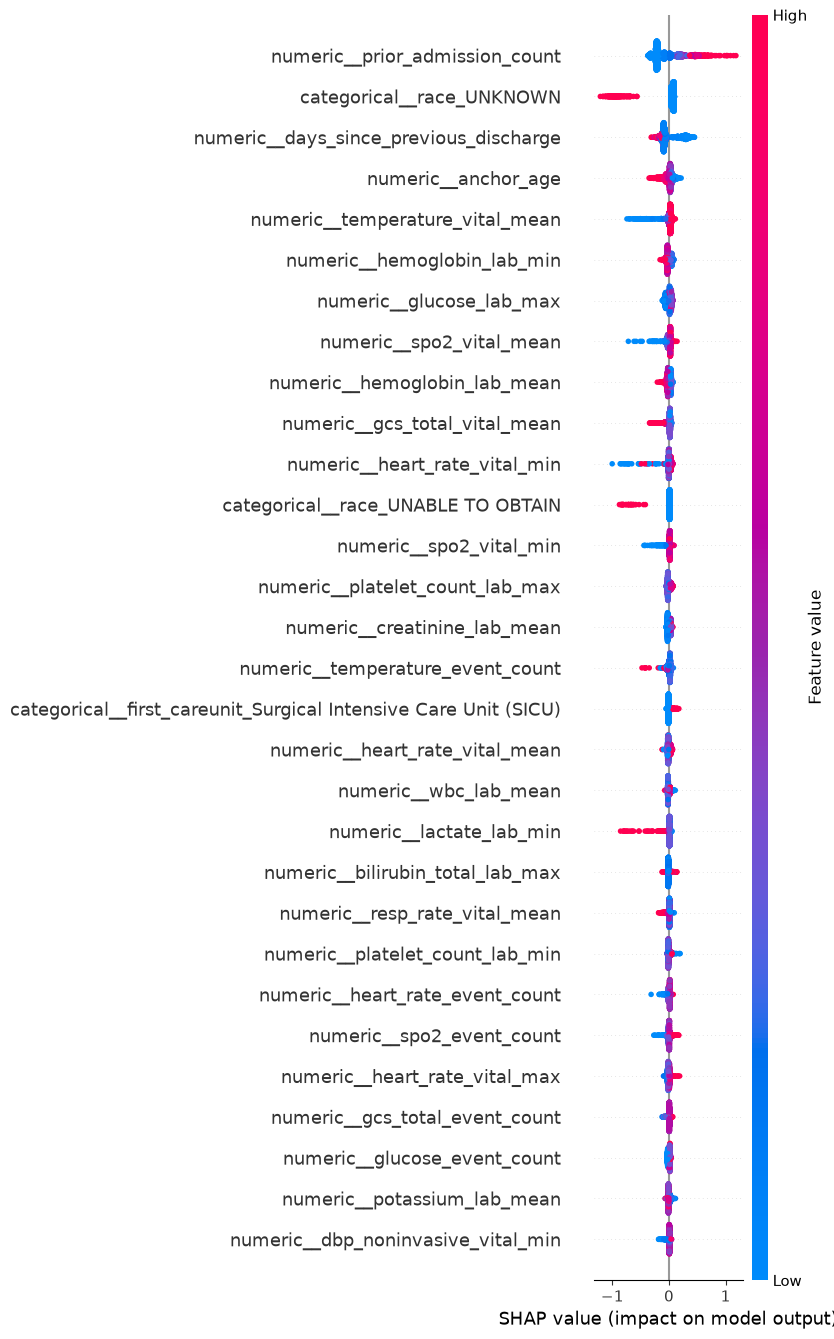

In [63]:
# ==========================================================
# SHAP explanations for the vitals + labs readmission model
# ==========================================================

import shap

# Explain 2,000 random test patients to keep SHAP reasonably fast
X_explain = X_test.sample(n=2000, random_state=42)

# Apply the exact preprocessing learned from X_train
X_explain_encoded = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .transform(X_explain)
)

# Get readable feature names after one-hot encoding
encoded_feature_names = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Convert sparse matrix into a normal dataframe for SHAP
if hasattr(X_explain_encoded, "toarray"):
    X_explain_encoded = X_explain_encoded.toarray()

X_explain_encoded = pd.DataFrame(
    X_explain_encoded,
    columns=encoded_feature_names,
    index=X_explain.index,
)

# Pull the trained XGBoost model out of the pipeline
trained_xgb_model = readmit_pipeline.named_steps["model"]

# Calculate SHAP values
explainer = shap.TreeExplainer(trained_xgb_model)
shap_values = explainer.shap_values(X_explain_encoded)

# Compatibility with some older SHAP versions
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ----------------------------------------------------------
# 1. Global feature-importance ranking
# ----------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_explain_encoded,
    plot_type="bar",
    max_display=30,
)

# ----------------------------------------------------------
# 2. Feature direction and impact
# ----------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_explain_encoded,
    max_display=30,
)

In [64]:
# ==========================================================
# Read first-24-hour urine-output events in chunks
# ==========================================================

from pathlib import Path
import pandas as pd

MIMIC_ROOT = Path(
    r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1"
)

outputevents_path = next(
    (MIMIC_ROOT / "icu").glob("outputevents.csv*")
)

# MIMIC-IV urine-output item IDs
urine_output_itemids = {
    226559: "foley_urine_output",
    226560: "voided_urine_output",
    226561: "condom_cath_urine_output",
    226563: "urostomy_output",
    226564: "nephrostomy_output",
    226565: "suprapubic_urine_output",
}

# One first-24-hour window per ICU stay
icu_windows = readmit_cohort[
    ["stay_id", "intime"]
].drop_duplicates("stay_id").copy()

icu_windows["first_24h_end"] = (
    icu_windows["intime"] + pd.Timedelta(hours=24)
)

urine_chunk_summaries = []

print(f"Reading: {outputevents_path.name}")

reader = pd.read_csv(
    outputevents_path,
    usecols=["stay_id", "charttime", "itemid", "value"],
    parse_dates=["charttime"],
    chunksize=1_000_000,
)

for chunk_number, chunk in enumerate(reader, start=1):

    # Keep selected urine-output events with valid non-negative volumes
    chunk = chunk[
        chunk["itemid"].isin(urine_output_itemids)
        & chunk["value"].notna()
        & (chunk["value"] >= 0)
    ]

    if not chunk.empty:

        # Attach each ICU stay's first-24-hour time window
        chunk = chunk.merge(
            icu_windows,
            on="stay_id",
            how="inner",
            validate="many_to_one",
        )

        # Keep events observed only in the first 24 ICU hours
        chunk = chunk[
            (chunk["charttime"] >= chunk["intime"])
            & (chunk["charttime"] < chunk["first_24h_end"])
        ]

        if not chunk.empty:

            # One partial urine summary per ICU stay
            chunk_summary = (
                chunk.groupby("stay_id")["value"]
                .agg(
                    urine_output_event_count="count",
                    urine_output_sum="sum",
                    urine_output_min="min",
                    urine_output_max="max",
                )
                .reset_index()
            )

            urine_chunk_summaries.append(chunk_summary)

    if chunk_number % 5 == 0:
        print(
            f"Processed {chunk_number:,} chunks "
            f"| kept {len(urine_chunk_summaries):,} non-empty summaries"
        )

print("\nFinished reading outputevents.")
print(f"Non-empty summaries collected: {len(urine_chunk_summaries):,}")

Reading: outputevents.csv.gz
Processed 5 chunks | kept 5 non-empty summaries

Finished reading outputevents.
Non-empty summaries collected: 6


In [65]:
# ==========================================================
# Finalize urine-output features and merge into cohort
# ==========================================================

if not urine_chunk_summaries:
    raise ValueError("No first-24-hour urine-output rows were found.")

urine_features = pd.concat(
    urine_chunk_summaries,
    ignore_index=True,
)

# Combine partial summaries from different chunks
urine_features = (
    urine_features
    .groupby("stay_id")
    .agg(
        urine_output_event_count=("urine_output_event_count", "sum"),
        urine_output_total_24h=("urine_output_sum", "sum"),
        urine_output_min=("urine_output_min", "min"),
        urine_output_max=("urine_output_max", "max"),
    )
    .reset_index()
)

urine_features["urine_output_mean"] = (
    urine_features["urine_output_total_24h"]
    / urine_features["urine_output_event_count"]
)

urine_output_feature_columns = [
    column
    for column in urine_features.columns
    if column != "stay_id"
]

# Safe to rerun: remove any prior version of these columns first
old_urine_columns = [
    column
    for column in readmit_cohort.columns
    if column in urine_output_feature_columns
    or any(
        column.startswith(f"{name}_")
        for name in urine_output_feature_columns
    )
]

readmit_cohort = readmit_cohort.drop(
    columns=old_urine_columns,
    errors="ignore",
)

# Merge one urine-output summary row onto each ICU stay
readmit_cohort = readmit_cohort.merge(
    urine_features,
    on="stay_id",
    how="left",
    validate="one_to_one",
)

print(f"Urine-output features created: {len(urine_output_feature_columns)}")
print(f"New readmit_cohort shape: {readmit_cohort.shape}")

print("\nUrine-output feature names:")
print(urine_output_feature_columns)

urine_coverage = (
    readmit_cohort["urine_output_total_24h"]
    .notna()
    .mean()
    * 100
)

print(f"\nUrine-output coverage: {urine_coverage:.2f}%")

Urine-output features created: 5
New readmit_cohort shape: (85242, 112)

Urine-output feature names:
['urine_output_event_count', 'urine_output_total_24h', 'urine_output_min', 'urine_output_max', 'urine_output_mean']

Urine-output coverage: 94.08%


Total rows: 85,242
Features: 100
Overall 30-day readmission rate: 18.09%

X_train shape: (68178, 100)
X_test shape:  (17064, 100)
Patients shared by train and test: 0
scale_pos_weight: 4.539
Model training complete.

Metrics at threshold = 0.5
Accuracy  : 0.650
Precision : 0.282
Recall    : 0.594
F1 score  : 0.382
ROC-AUC   : 0.685
PR-AUC    : 0.334

Threshold comparison:
 threshold  recall  precision  accuracy    f1
      0.10   0.997      0.185     0.200 0.313
      0.15   0.992      0.188     0.220 0.317
      0.20   0.982      0.195     0.257 0.325
      0.25   0.972      0.200     0.285 0.331
      0.30   0.959      0.205     0.314 0.338
      0.35   0.928      0.212     0.357 0.345
      0.40   0.855      0.227     0.443 0.359
      0.45   0.742      0.254     0.556 0.379
      0.50   0.594      0.282     0.650 0.382
      0.55   0.462      0.319     0.722 0.377
      0.60   0.350      0.358     0.767 0.354
      0.65   0.254      0.405     0.796 0.312
      0.70   0.156      0.4

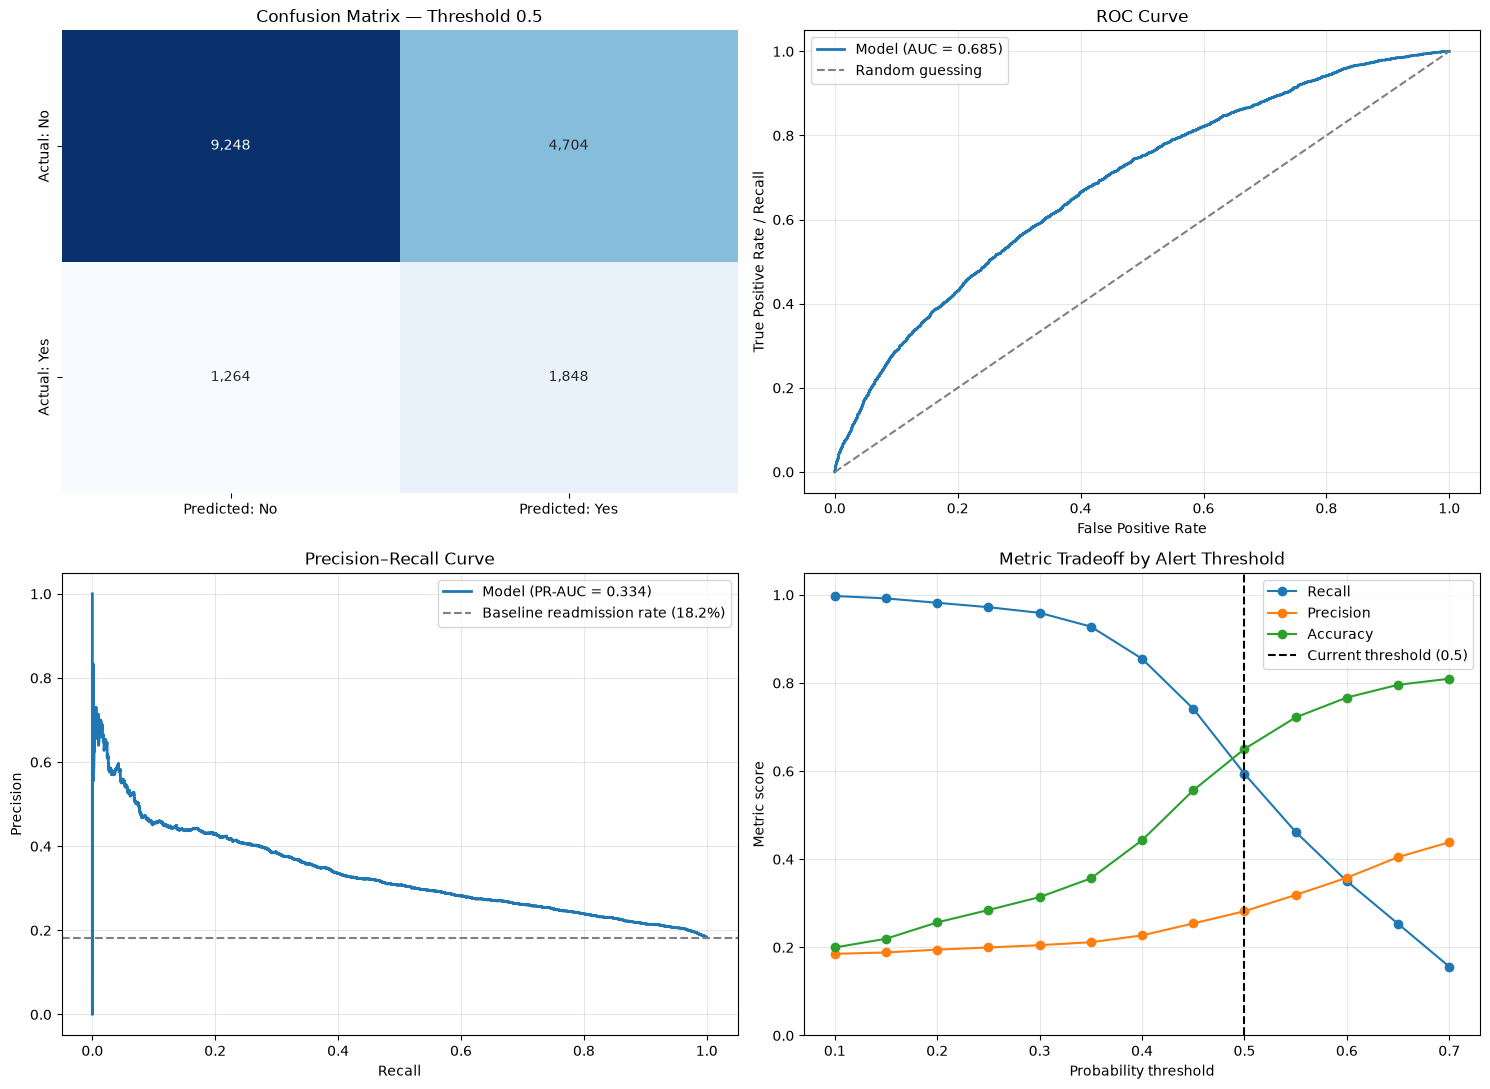

In [66]:

# ==========================================================
# Readmission model: vitals + labs + history
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier


# 1. Select safe features
feature_columns = [
    # Admission-time features
    "first_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # Prior-history features
    "days_since_previous_discharge",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
    "prior_admission_count",
    "previous_hospital_los_days",

    # First-24-hour vitals
    *vital_feature_columns,

    # First-24-hour labs
    *lab_feature_columns,

    # First-24-hour urine output
    *urine_output_feature_columns,
]


missing_columns = [
    column
    for column in feature_columns
    if column not in readmit_cohort.columns
]

if missing_columns:
    raise ValueError(f"Missing feature columns: {missing_columns}")

X = readmit_cohort[feature_columns].copy()
y = readmit_cohort["readmit_30d"].copy()
groups = readmit_cohort["subject_id"].copy()

print(f"Total rows: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"Overall 30-day readmission rate: {y.mean():.2%}")


# 2. Patient-safe split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

train_patients = set(groups.iloc[train_index])
test_patients = set(groups.iloc[test_index])

print(f"Patients shared by train and test: {len(train_patients & test_patients)}")


# 3. Preprocess numbers and text
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_train.columns.difference(
    categorical_features
).tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
)


# 4. Train XGBoost
number_of_zeros = (y_train == 0).sum()
number_of_ones = (y_train == 1).sum()

scale_pos_weight = number_of_zeros / number_of_ones

print(f"scale_pos_weight: {scale_pos_weight:.3f}")

readmit_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

readmit_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", readmit_model),
])

readmit_pipeline.fit(X_train, y_train)

print("Model training complete.")


# 5. Predictions and metrics
y_pred_proba = readmit_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.50
y_pred = (y_pred_proba >= threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
    "PR-AUC": average_precision_score(y_test, y_pred_proba),
}

print(f"\nMetrics at threshold = {threshold}")

for name, value in metrics.items():
    print(f"{name:<10}: {value:.3f}")


# 6. Threshold comparison
threshold_values = np.arange(0.10, 0.71, 0.05)
threshold_results = []

for t in threshold_values:
    predicted_at_t = (y_pred_proba >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "recall": recall_score(y_test, predicted_at_t, zero_division=0),
        "precision": precision_score(y_test, predicted_at_t, zero_division=0),
        "accuracy": accuracy_score(y_test, predicted_at_t),
        "f1": f1_score(y_test, predicted_at_t, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_results)

print("\nThreshold comparison:")
print(threshold_results.round(3).to_string(index=False))


# 7. Plots
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_proba,
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)
axes[0, 0].set_title(f"Confusion Matrix — Threshold {threshold}")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

# ROC curve
axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Model (AUC = {metrics['ROC-AUC']:.3f})",
)
axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random guessing",
)
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate / Recall")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision-recall curve
baseline_rate = y_test.mean()

axes[1, 0].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Model (PR-AUC = {metrics['PR-AUC']:.3f})",
)
axes[1, 0].axhline(
    baseline_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline readmission rate ({baseline_rate:.1%})",
)
axes[1, 0].set_title("Precision–Recall Curve")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Threshold tradeoff
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    marker="o",
    label="Accuracy",
)
axes[1, 1].axvline(
    threshold,
    linestyle="--",
    color="black",
    label=f"Current threshold ({threshold})",
)
axes[1, 1].set_title("Metric Tradeoff by Alert Threshold")
axes[1, 1].set_xlabel("Probability threshold")
axes[1, 1].set_ylabel("Metric score")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

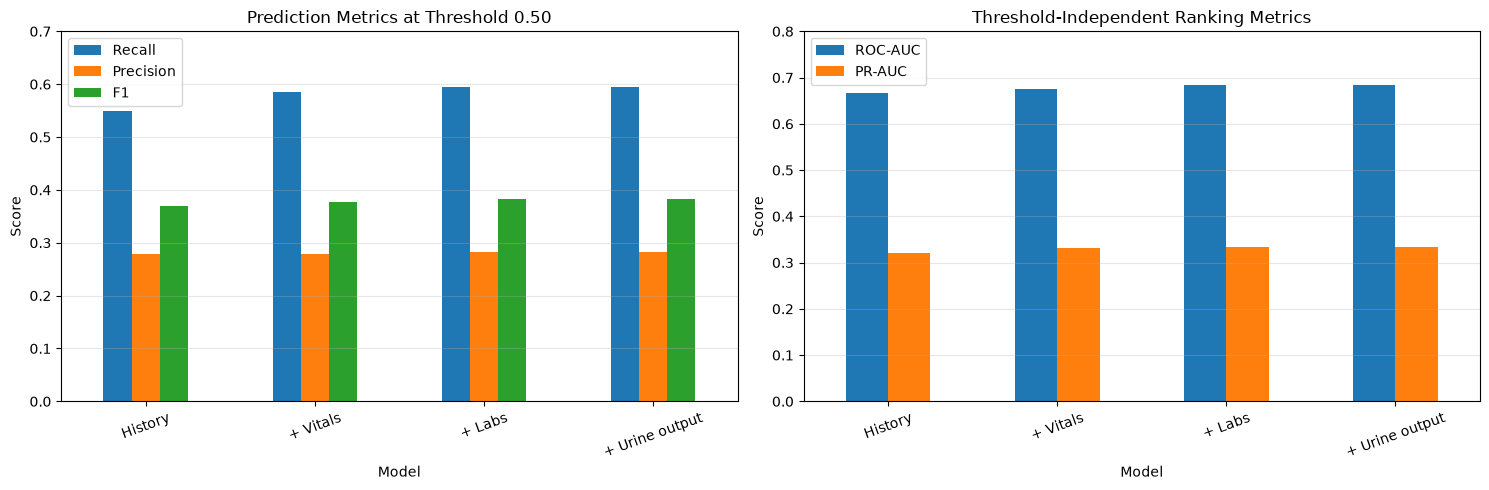

In [67]:
comparison = pd.DataFrame({
    "Model": [
        "History",
        "+ Vitals",
        "+ Labs",
        "+ Urine output",
    ],
    "Recall": [0.550, 0.585, 0.594, 0.594],
    "Precision": [0.278, 0.278, 0.282, 0.282],
    "F1": [0.369, 0.377, 0.383, 0.382],
    "ROC-AUC": [0.667, 0.676, 0.685, 0.685],
    "PR-AUC": [0.320, 0.331, 0.334, 0.334],
})

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

comparison.set_index("Model").plot(
    y=["Recall", "Precision", "F1"],
    kind="bar",
    ax=axes[0],
)
axes[0].set_title("Prediction Metrics at Threshold 0.50")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 0.7)
axes[0].tick_params(axis="x", rotation=20)
axes[0].grid(axis="y", alpha=0.3)

comparison.set_index("Model").plot(
    y=["ROC-AUC", "PR-AUC"],
    kind="bar",
    ax=axes[1],
)
axes[1].set_title("Threshold-Independent Ranking Metrics")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 0.8)
axes[1].tick_params(axis="x", rotation=20)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [68]:
# ==========================================================
# Read first-24-hour input/treatment events in chunks
# ==========================================================

from pathlib import Path
import pandas as pd

MIMIC_ROOT = Path(
    r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1"
)

inputevents_path = next(
    (MIMIC_ROOT / "icu").glob("inputevents.csv*")
)

# Common MIMIC-IV vasopressor item IDs
vasopressor_itemids = {
    221906: "norepinephrine",
    221289: "epinephrine",
    221662: "dopamine",
    221653: "dobutamine",
    221749: "phenylephrine",
    222315: "vasopressin",
}

icu_windows = readmit_cohort[
    ["stay_id", "intime"]
].drop_duplicates("stay_id").copy()

icu_windows["first_24h_end"] = (
    icu_windows["intime"] + pd.Timedelta(hours=24)
)

input_chunk_summaries = []

print(f"Reading: {inputevents_path.name}")

reader = pd.read_csv(
    inputevents_path,
    usecols=["stay_id", "starttime", "itemid"],
    parse_dates=["starttime"],
    chunksize=1_000_000,
)

for chunk_number, chunk in enumerate(reader, start=1):

    # Keep only input events for ICU stays in our modeling cohort
    chunk = chunk.merge(
        icu_windows,
        on="stay_id",
        how="inner",
        validate="many_to_one",
    )

    # Strict first-24-hour rule
    chunk = chunk[
        (chunk["starttime"] >= chunk["intime"])
        & (chunk["starttime"] < chunk["first_24h_end"])
    ]

    if not chunk.empty:

        # Keep one row per stay and treatment item within this chunk
        chunk_summary = (
            chunk.groupby(["stay_id", "itemid"])
            .size()
            .reset_index(name="input_event_count")
        )

        input_chunk_summaries.append(chunk_summary)

    if chunk_number % 10 == 0:
        print(
            f"Processed {chunk_number:,} chunks "
            f"| kept {len(input_chunk_summaries):,} non-empty summaries"
        )

print("\nFinished reading inputevents.")
print(f"Non-empty summaries collected: {len(input_chunk_summaries):,}")

Reading: inputevents.csv.gz
Processed 10 chunks | kept 10 non-empty summaries

Finished reading inputevents.
Non-empty summaries collected: 11


In [69]:
# ==========================================================
# Finalize input/treatment features and merge into cohort
# ==========================================================

if not input_chunk_summaries:
    raise ValueError("No first-24-hour input events were found.")

input_long = pd.concat(
    input_chunk_summaries,
    ignore_index=True,
)

# Combine treatment counts from different chunks
input_long = (
    input_long
    .groupby(["stay_id", "itemid"])["input_event_count"]
    .sum()
    .reset_index()
)

# One compact treatment-intensity row per ICU stay
input_features = (
    input_long
    .groupby("stay_id")
    .agg(
        input_event_count_24h=("input_event_count", "sum"),
        distinct_input_item_count_24h=("itemid", "nunique"),
    )
    .reset_index()
)

# Add vasopressor-specific features
vasopressor_features = (
    input_long[
        input_long["itemid"].isin(vasopressor_itemids)
    ]
    .groupby("stay_id")
    .agg(
        vasopressor_event_count_24h=("input_event_count", "sum"),
    )
    .reset_index()
)

vasopressor_features["vasopressor_started_24h"] = 1

input_features = input_features.merge(
    vasopressor_features,
    on="stay_id",
    how="left",
)

# No vasopressor event means zero
input_features["vasopressor_event_count_24h"] = (
    input_features["vasopressor_event_count_24h"]
    .fillna(0)
)

input_features["vasopressor_started_24h"] = (
    input_features["vasopressor_started_24h"]
    .fillna(0)
    .astype(int)
)

input_feature_columns = [
    column
    for column in input_features.columns
    if column != "stay_id"
]

# Safe to rerun: remove prior versions before merging
old_input_columns = [
    column
    for column in readmit_cohort.columns
    if column in input_feature_columns
    or any(
        column.startswith(f"{name}_")
        for name in input_feature_columns
    )
]

readmit_cohort = readmit_cohort.drop(
    columns=old_input_columns,
    errors="ignore",
)

readmit_cohort = readmit_cohort.merge(
    input_features,
    on="stay_id",
    how="left",
    validate="one_to_one",
)

print(f"Input/treatment features created: {len(input_feature_columns)}")
print(f"New readmit_cohort shape: {readmit_cohort.shape}")

print("\nInput feature names:")
print(input_feature_columns)

vasopressor_coverage = (
    readmit_cohort["vasopressor_started_24h"]
    .mean()
    * 100
)

print(
    f"\nPatients with an early vasopressor event: "
    f"{vasopressor_coverage:.2f}%"
)

Input/treatment features created: 4
New readmit_cohort shape: (85242, 116)

Input feature names:
['input_event_count_24h', 'distinct_input_item_count_24h', 'vasopressor_event_count_24h', 'vasopressor_started_24h']

Patients with an early vasopressor event: 28.20%


Total rows: 85,242
Features: 104
Overall 30-day readmission rate: 18.09%

X_train shape: (68178, 104)
X_test shape:  (17064, 104)
Patients shared by train and test: 0
scale_pos_weight: 4.539
Model training complete.

Metrics at threshold = 0.5
Accuracy  : 0.652
Precision : 0.283
Recall    : 0.596
F1 score  : 0.384
ROC-AUC   : 0.687
PR-AUC    : 0.339

Threshold comparison:
 threshold  recall  precision  accuracy    f1
      0.10   0.997      0.185     0.200 0.312
      0.15   0.992      0.189     0.222 0.317
      0.20   0.983      0.195     0.258 0.326
      0.25   0.972      0.200     0.286 0.332
      0.30   0.957      0.204     0.312 0.337
      0.35   0.925      0.212     0.359 0.345
      0.40   0.853      0.227     0.444 0.359
      0.45   0.738      0.253     0.555 0.377
      0.50   0.596      0.283     0.652 0.384
      0.55   0.464      0.320     0.722 0.378
      0.60   0.353      0.363     0.769 0.358
      0.65   0.255      0.411     0.797 0.315
      0.70   0.159      0.4

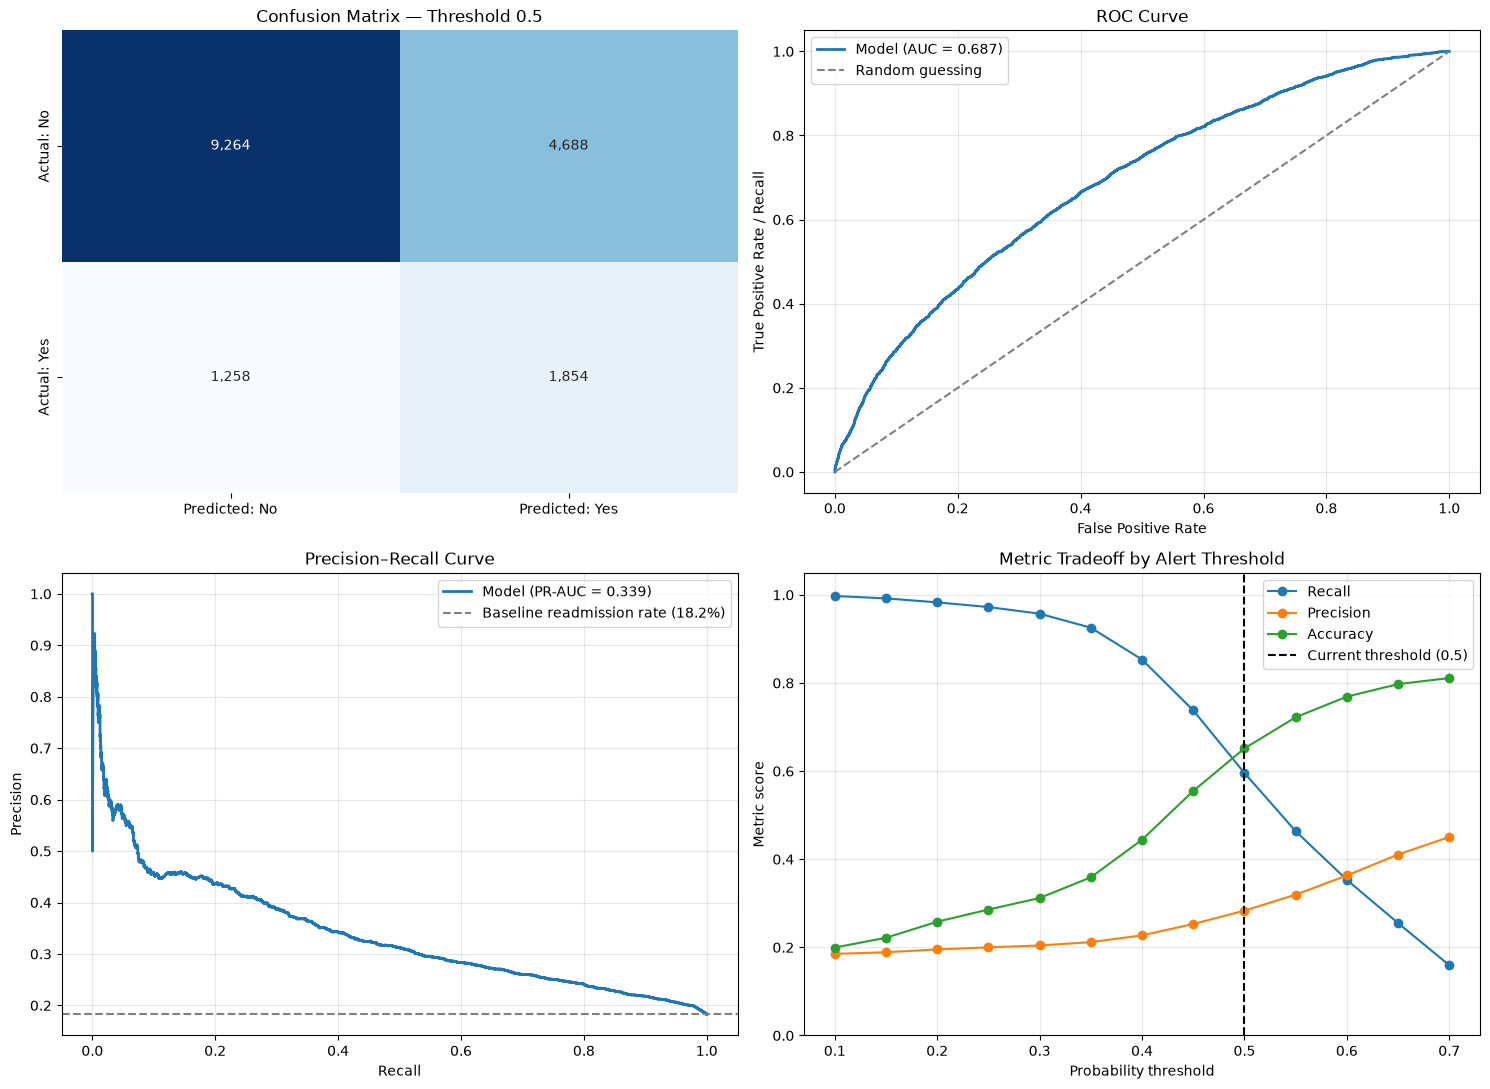

In [70]:

# ==========================================================
# Readmission model: vitals + labs + history
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier


# 1. Select safe features
feature_columns = [
    # Admission-time features
    "first_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # Prior-history features
    "days_since_previous_discharge",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
    "prior_admission_count",
    "previous_hospital_los_days",

    # First-24-hour vitals
    *vital_feature_columns,

    # First-24-hour labs
    *lab_feature_columns,

    # First-24-hour urine output
    *urine_output_feature_columns,
    *input_feature_columns
]


missing_columns = [
    column
    for column in feature_columns
    if column not in readmit_cohort.columns
]

if missing_columns:
    raise ValueError(f"Missing feature columns: {missing_columns}")

X = readmit_cohort[feature_columns].copy()
y = readmit_cohort["readmit_30d"].copy()
groups = readmit_cohort["subject_id"].copy()

print(f"Total rows: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"Overall 30-day readmission rate: {y.mean():.2%}")


# 2. Patient-safe split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

train_patients = set(groups.iloc[train_index])
test_patients = set(groups.iloc[test_index])

print(f"Patients shared by train and test: {len(train_patients & test_patients)}")


# 3. Preprocess numbers and text
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_train.columns.difference(
    categorical_features
).tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
)


# 4. Train XGBoost
number_of_zeros = (y_train == 0).sum()
number_of_ones = (y_train == 1).sum()

scale_pos_weight = number_of_zeros / number_of_ones

print(f"scale_pos_weight: {scale_pos_weight:.3f}")

readmit_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

readmit_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", readmit_model),
])

readmit_pipeline.fit(X_train, y_train)

print("Model training complete.")


# 5. Predictions and metrics
y_pred_proba = readmit_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.50
y_pred = (y_pred_proba >= threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
    "PR-AUC": average_precision_score(y_test, y_pred_proba),
}

print(f"\nMetrics at threshold = {threshold}")

for name, value in metrics.items():
    print(f"{name:<10}: {value:.3f}")


# 6. Threshold comparison
threshold_values = np.arange(0.10, 0.71, 0.05)
threshold_results = []

for t in threshold_values:
    predicted_at_t = (y_pred_proba >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "recall": recall_score(y_test, predicted_at_t, zero_division=0),
        "precision": precision_score(y_test, predicted_at_t, zero_division=0),
        "accuracy": accuracy_score(y_test, predicted_at_t),
        "f1": f1_score(y_test, predicted_at_t, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_results)

print("\nThreshold comparison:")
print(threshold_results.round(3).to_string(index=False))


# 7. Plots
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_proba,
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)
axes[0, 0].set_title(f"Confusion Matrix — Threshold {threshold}")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

# ROC curve
axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Model (AUC = {metrics['ROC-AUC']:.3f})",
)
axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random guessing",
)
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate / Recall")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision-recall curve
baseline_rate = y_test.mean()

axes[1, 0].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Model (PR-AUC = {metrics['PR-AUC']:.3f})",
)
axes[1, 0].axhline(
    baseline_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline readmission rate ({baseline_rate:.1%})",
)
axes[1, 0].set_title("Precision–Recall Curve")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Threshold tradeoff
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    marker="o",
    label="Accuracy",
)
axes[1, 1].axvline(
    threshold,
    linestyle="--",
    color="black",
    label=f"Current threshold ({threshold})",
)
axes[1, 1].set_title("Metric Tradeoff by Alert Threshold")
axes[1, 1].set_xlabel("Probability threshold")
axes[1, 1].set_ylabel("Metric score")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

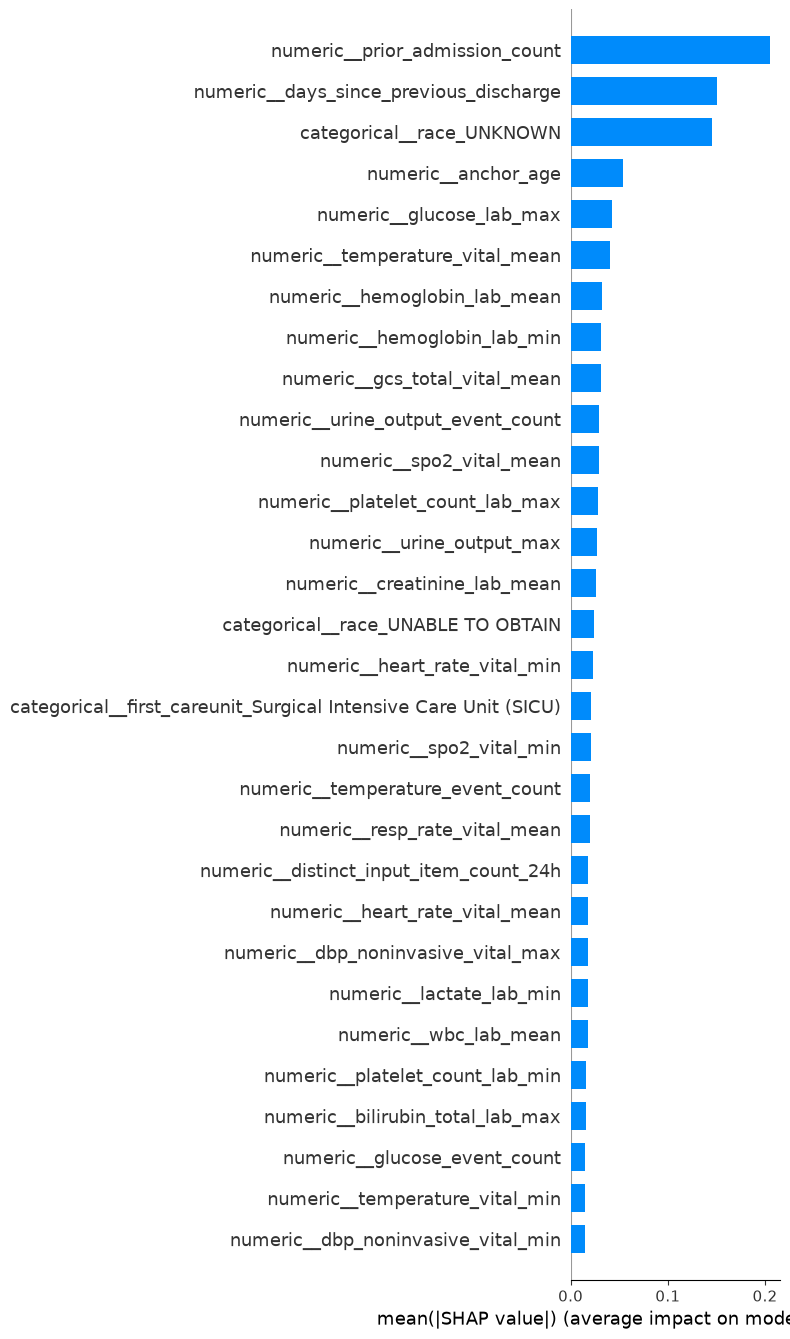

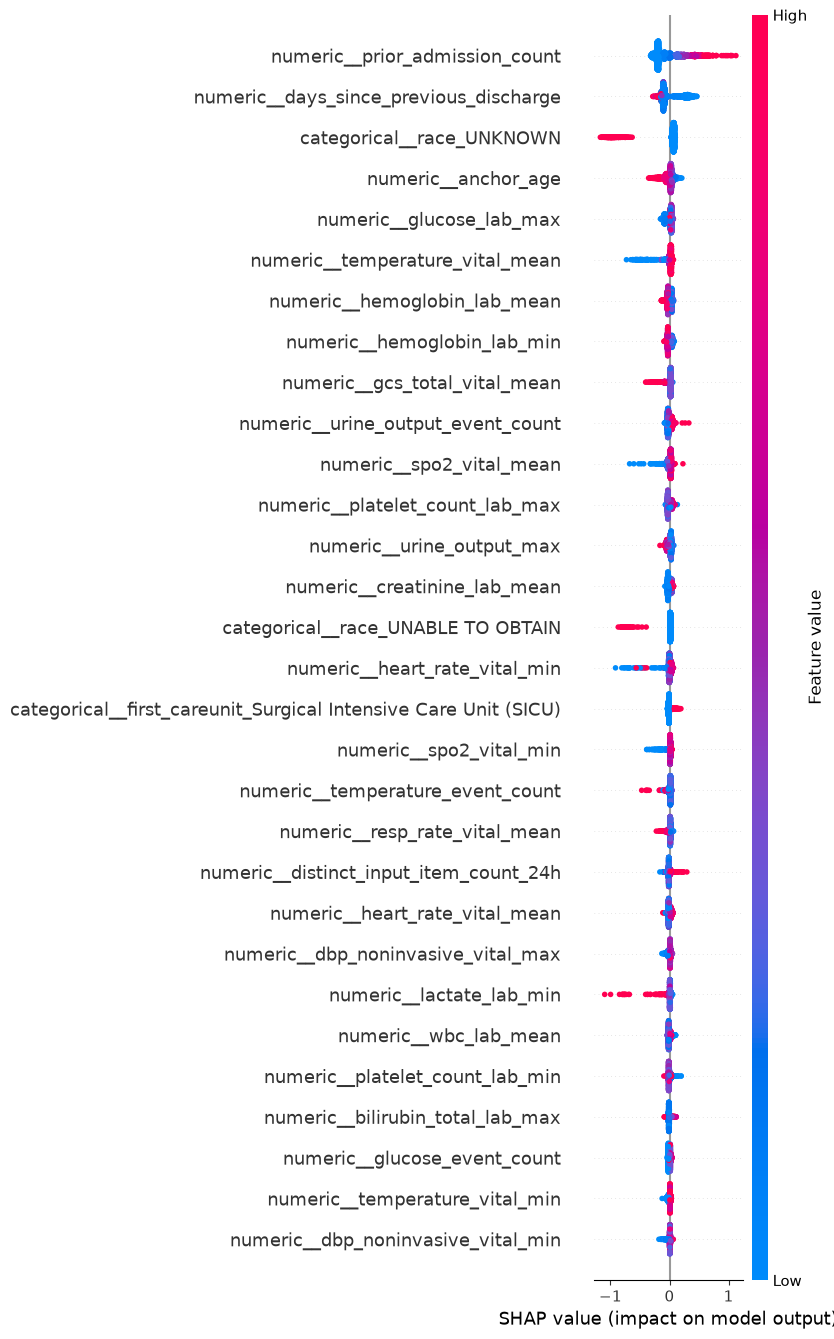

In [71]:
X_explain = X_test.sample(n=2000, random_state=42)

# Apply the exact preprocessing learned from X_train
X_explain_encoded = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .transform(X_explain)
)

# Get readable feature names after one-hot encoding
encoded_feature_names = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Convert sparse matrix into a normal dataframe for SHAP
if hasattr(X_explain_encoded, "toarray"):
    X_explain_encoded = X_explain_encoded.toarray()

X_explain_encoded = pd.DataFrame(
    X_explain_encoded,
    columns=encoded_feature_names,
    index=X_explain.index,
)

# Pull the trained XGBoost model out of the pipeline
trained_xgb_model = readmit_pipeline.named_steps["model"]

# Calculate SHAP values
explainer = shap.TreeExplainer(trained_xgb_model)
shap_values = explainer.shap_values(X_explain_encoded)

# Compatibility with some older SHAP versions
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ----------------------------------------------------------
# 1. Global feature-importance ranking
# ----------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_explain_encoded,
    plot_type="bar",
    max_display=30,
)

# ----------------------------------------------------------
# 2. Feature direction and impact
# ----------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_explain_encoded,
    max_display=30,
)

In [73]:
# ==========================================================
# One-cell feature bundle:
# prior comorbidities + early microbiology + early medications
# ==========================================================

from pathlib import Path
import pandas as pd

MIMIC_ROOT = Path(
    r"E:\MedAgent\data\raw\physionet.org\files\mimiciv\3.1"
)

HOSP_PATH = MIMIC_ROOT / "hosp"


# ----------------------------------------------------------
# Helper: safely replace and merge a feature block
# ----------------------------------------------------------

def merge_feature_block(cohort, feature_table, key, feature_columns):

    old_columns = [
        column
        for column in cohort.columns
        if column in feature_columns
        or any(
            column.startswith(f"{name}_")
            for name in feature_columns
        )
    ]

    cohort = cohort.drop(columns=old_columns, errors="ignore")

    cohort = cohort.merge(
        feature_table,
        on=key,
        how="left",
        validate="many_to_one",
    )

    return cohort


# ==========================================================
# 1. PRIOR COMORBIDITY HISTORY
# Uses only diagnoses from admissions BEFORE the current one
# ==========================================================

diagnoses_path = next(HOSP_PATH.glob("diagnoses_icd.csv*"))

diagnoses = pd.read_csv(
    diagnoses_path,
    usecols=["subject_id", "hadm_id", "icd_code", "icd_version"],
    dtype={"icd_code": "string"},
)

diagnoses["icd_code"] = (
    diagnoses["icd_code"]
    .str.upper()
    .str.replace(".", "", regex=False)
    .fillna("")
)

# Clinically meaningful prior-diagnosis groups
diagnoses["diabetes_flag"] = (
    diagnoses["icd_code"].str.startswith(
        ("250", "E08", "E09", "E10", "E11", "E13")
    )
).astype(int)

diagnoses["heart_failure_flag"] = (
    diagnoses["icd_code"].str.startswith(("428", "I50"))
).astype(int)

diagnoses["ckd_flag"] = (
    diagnoses["icd_code"].str.startswith(("585", "N18"))
).astype(int)

diagnoses["copd_flag"] = (
    diagnoses["icd_code"].str.startswith(
        ("490", "491", "492", "493", "494", "495", "496",
         "J40", "J41", "J42", "J43", "J44", "J45", "J46", "J47")
    )
).astype(int)

diagnoses["liver_disease_flag"] = (
    diagnoses["icd_code"].str.startswith(
        ("570", "571", "572", "573",
         "K70", "K71", "K72", "K73", "K74", "K75", "K76", "K77")
    )
).astype(int)

icd9_prefix = pd.to_numeric(
    diagnoses["icd_code"].str[:3],
    errors="coerce",
)

diagnoses["cancer_flag"] = (
    diagnoses["icd_code"].str.startswith("C", na=False)
    | icd9_prefix.between(140, 209).fillna(False)
).astype(int)

# Summarize diagnosis information within each hospital admission
hadm_diagnoses = (
    diagnoses
    .groupby(["subject_id", "hadm_id"])
    .agg(
        diagnosis_code_count=("icd_code", "size"),
        diabetes_flag=("diabetes_flag", "max"),
        heart_failure_flag=("heart_failure_flag", "max"),
        ckd_flag=("ckd_flag", "max"),
        copd_flag=("copd_flag", "max"),
        liver_disease_flag=("liver_disease_flag", "max"),
        cancer_flag=("cancer_flag", "max"),
    )
    .reset_index()
)

# Start from all admissions in chronological order
admission_history = admissions[
    ["subject_id", "hadm_id", "admittime"]
].drop_duplicates("hadm_id").copy()

admission_history = admission_history.merge(
    hadm_diagnoses,
    on=["subject_id", "hadm_id"],
    how="left",
    validate="one_to_one",
)

diagnosis_columns = [
    "diagnosis_code_count",
    "diabetes_flag",
    "heart_failure_flag",
    "ckd_flag",
    "copd_flag",
    "liver_disease_flag",
    "cancer_flag",
]

admission_history[diagnosis_columns] = (
    admission_history[diagnosis_columns]
    .fillna(0)
    .astype(int)
)

admission_history = admission_history.sort_values(
    ["subject_id", "admittime"]
).reset_index(drop=True)

# Look backward only: no current-admission diagnosis information is used
admission_history["prior_diagnosis_code_count"] = (
    admission_history
    .groupby("subject_id")["diagnosis_code_count"]
    .transform(lambda series: series.shift().cumsum())
    .fillna(0)
)

condition_names = [
    "diabetes",
    "heart_failure",
    "ckd",
    "copd",
    "liver_disease",
    "cancer",
]

for condition in condition_names:

    admission_history[f"prior_{condition}_flag"] = (
        admission_history
        .groupby("subject_id")[f"{condition}_flag"]
        .transform(lambda series: series.shift().cummax())
        .fillna(0)
        .astype(int)
    )

prior_diagnosis_feature_columns = [
    "prior_diagnosis_code_count",
    "prior_diabetes_flag",
    "prior_heart_failure_flag",
    "prior_ckd_flag",
    "prior_copd_flag",
    "prior_liver_disease_flag",
    "prior_cancer_flag",
]

prior_diagnosis_features = admission_history[
    ["subject_id", "hadm_id", *prior_diagnosis_feature_columns]
].copy()

readmit_cohort = merge_feature_block(
    cohort=readmit_cohort,
    feature_table=prior_diagnosis_features,
    key=["subject_id", "hadm_id"],
    feature_columns=prior_diagnosis_feature_columns,
)

print(
    f"Prior-diagnosis features merged: "
    f"{len(prior_diagnosis_feature_columns)}"
)


# ==========================================================
# 2. FIRST-24-HOUR MICROBIOLOGY / INFECTION-WORKUP FEATURES
# ==========================================================

micro_path = next(HOSP_PATH.glob("microbiologyevents.csv*"))

admission_windows = readmit_cohort[
    ["hadm_id", "intime"]
].drop_duplicates("hadm_id").copy()

admission_windows["first_24h_end"] = (
    admission_windows["intime"] + pd.Timedelta(hours=24)
)

micro_parts = []

print(f"\nReading: {micro_path.name}")

micro_reader = pd.read_csv(
    micro_path,
    usecols=[
        "hadm_id",
        "chartdate",
        "charttime",
        "spec_type_desc",
        "org_name",
    ],
    parse_dates=["chartdate", "charttime"],
    chunksize=1_000_000,
)

for chunk_number, chunk in enumerate(micro_reader, start=1):

    chunk = chunk[chunk["hadm_id"].notna()].copy()

    if not chunk.empty:

        chunk["hadm_id"] = chunk["hadm_id"].astype("int64")

        # Prefer exact charttime; fall back to chartdate if needed
        chunk["event_time"] = chunk["charttime"].fillna(
            chunk["chartdate"]
        )

        chunk = chunk.merge(
            admission_windows,
            on="hadm_id",
            how="inner",
            validate="many_to_one",
        )

        chunk = chunk[
            (chunk["event_time"] >= chunk["intime"])
            & (chunk["event_time"] < chunk["first_24h_end"])
        ]

        if not chunk.empty:

            chunk["organism_detected"] = (
                chunk["org_name"].notna()
            ).astype(int)

            micro_parts.append(
                chunk.groupby("hadm_id")
                .agg(
                    micro_event_count_24h=("hadm_id", "size"),
                    organism_detected_event_count_24h=(
                        "organism_detected",
                        "sum",
                    ),
                )
                .reset_index()
            )

    if chunk_number % 10 == 0:
        print(f"Processed {chunk_number:,} microbiology chunks")

if micro_parts:

    microbiology_features = (
        pd.concat(micro_parts, ignore_index=True)
        .groupby("hadm_id")
        .sum()
        .reset_index()
    )

else:
    microbiology_features = pd.DataFrame(
        columns=[
            "hadm_id",
            "micro_event_count_24h",
            "organism_detected_event_count_24h",
        ]
    )

microbiology_feature_columns = [
    "micro_event_count_24h",
    "organism_detected_event_count_24h",
]

readmit_cohort = merge_feature_block(
    cohort=readmit_cohort,
    feature_table=microbiology_features,
    key="hadm_id",
    feature_columns=microbiology_feature_columns,
)

print(
    f"Microbiology features merged: "
    f"{len(microbiology_feature_columns)}"
)


# ==========================================================
# 3. FIRST-24-HOUR MEDICATION-BURDEN FEATURES
# ==========================================================

prescriptions_path = next(HOSP_PATH.glob("prescriptions.csv*"))

medication_count_parts = []
medication_pair_parts = []

print(f"\nReading: {prescriptions_path.name}")

medication_reader = pd.read_csv(
    prescriptions_path,
    usecols=["hadm_id", "starttime", "medication"],
    parse_dates=["starttime"],
    chunksize=1_000_000,
)

for chunk_number, chunk in enumerate(medication_reader, start=1):

    chunk = chunk[
        chunk["hadm_id"].notna()
        & chunk["medication"].notna()
    ].copy()

    if not chunk.empty:

        chunk["hadm_id"] = chunk["hadm_id"].astype("int64")

        chunk = chunk.merge(
            admission_windows,
            on="hadm_id",
            how="inner",
            validate="many_to_one",
        )

        chunk = chunk[
            (chunk["starttime"] >= chunk["intime"])
            & (chunk["starttime"] < chunk["first_24h_end"])
        ]

        if not chunk.empty:

            medication_count_parts.append(
                chunk.groupby("hadm_id")
                .size()
                .reset_index(name="medication_event_count_24h")
            )

            medication_pair_parts.append(
                chunk[["hadm_id", "medication"]]
                .drop_duplicates()
            )

    if chunk_number % 10 == 0:
        print(f"Processed {chunk_number:,} prescription chunks")

if medication_count_parts:

    medication_event_counts = (
        pd.concat(medication_count_parts, ignore_index=True)
        .groupby("hadm_id")["medication_event_count_24h"]
        .sum()
        .reset_index()
    )

    unique_medication_pairs = (
        pd.concat(medication_pair_parts, ignore_index=True)
        .drop_duplicates()
    )

    medication_distinct_counts = (
        unique_medication_pairs
        .groupby("hadm_id")
        .size()
        .reset_index(name="distinct_medication_count_24h")
    )

    medication_features = medication_event_counts.merge(
        medication_distinct_counts,
        on="hadm_id",
        how="outer",
    )

else:
    medication_features = pd.DataFrame(
        columns=[
            "hadm_id",
            "medication_event_count_24h",
            "distinct_medication_count_24h",
        ]
    )

medication_feature_columns = [
    "medication_event_count_24h",
    "distinct_medication_count_24h",
]

readmit_cohort = merge_feature_block(
    cohort=readmit_cohort,
    feature_table=medication_features,
    key="hadm_id",
    feature_columns=medication_feature_columns,
)

print(
    f"Medication features merged: "
    f"{len(medication_feature_columns)}"
)


# ==========================================================
# Final combined feature-list shortcut for your model cell
# ==========================================================

remaining_feature_columns = [
    *prior_diagnosis_feature_columns,
    *microbiology_feature_columns,
    *medication_feature_columns,
]

print("\nAll remaining feature columns:")
print(remaining_feature_columns)

print(f"\nFinal readmit_cohort shape: {readmit_cohort.shape}")

Prior-diagnosis features merged: 7

Reading: microbiologyevents.csv.gz
Microbiology features merged: 2

Reading: prescriptions.csv.gz


ValueError: Usecols do not match columns, columns expected but not found: ['medication']

In [74]:
print("Prior diagnosis features:")
print(prior_diagnosis_feature_columns)

print("\nMicrobiology features:")
print(microbiology_feature_columns)

print("\nWhich ones are currently in readmit_cohort?")

successful_new_columns = [
    column
    for column in (
        prior_diagnosis_feature_columns
        + microbiology_feature_columns
    )
    if column in readmit_cohort.columns
]

print(successful_new_columns)

Prior diagnosis features:
['prior_diagnosis_code_count', 'prior_diabetes_flag', 'prior_heart_failure_flag', 'prior_ckd_flag', 'prior_copd_flag', 'prior_liver_disease_flag', 'prior_cancer_flag']

Microbiology features:
['micro_event_count_24h', 'organism_detected_event_count_24h']

Which ones are currently in readmit_cohort?
['prior_diagnosis_code_count', 'prior_diabetes_flag', 'prior_heart_failure_flag', 'prior_ckd_flag', 'prior_copd_flag', 'prior_liver_disease_flag', 'prior_cancer_flag', 'micro_event_count_24h', 'organism_detected_event_count_24h']


In [75]:
prescriptions_path = next(
    (MIMIC_ROOT / "hosp").glob("prescriptions.csv*")
)

prescription_header = pd.read_csv(
    prescriptions_path,
    nrows=1,
)

print(prescription_header.columns.tolist())

['subject_id', 'hadm_id', 'pharmacy_id', 'poe_id', 'poe_seq', 'order_provider_id', 'starttime', 'stoptime', 'drug_type', 'drug', 'formulary_drug_cd', 'gsn', 'ndc', 'prod_strength', 'form_rx', 'dose_val_rx', 'dose_unit_rx', 'form_val_disp', 'form_unit_disp', 'doses_per_24_hrs', 'route']


In [76]:
# ==========================================================
# First-24-hour prescription features
# ==========================================================

import pandas as pd

# Existing diagnosis/microbiology count features:
# no event should mean 0, not an imputed median
readmit_cohort[
    prior_diagnosis_feature_columns + microbiology_feature_columns
] = readmit_cohort[
    prior_diagnosis_feature_columns + microbiology_feature_columns
].fillna(0)

prescriptions_path = next(
    (MIMIC_ROOT / "hosp").glob("prescriptions.csv*")
)

# One first-24-hour window per hospital admission
admission_windows = readmit_cohort[
    ["hadm_id", "intime"]
].drop_duplicates("hadm_id").copy()

admission_windows["first_24h_end"] = (
    admission_windows["intime"] + pd.Timedelta(hours=24)
)

prescription_count_parts = []
drug_pair_parts = []
route_pair_parts = []

print(f"Reading: {prescriptions_path.name}")

reader = pd.read_csv(
    prescriptions_path,
    usecols=["hadm_id", "starttime", "drug", "route"],
    parse_dates=["starttime"],
    chunksize=1_000_000,
)

for chunk_number, chunk in enumerate(reader, start=1):

    chunk = chunk[
        chunk["hadm_id"].notna()
        & chunk["drug"].notna()
    ].copy()

    if not chunk.empty:

        chunk["hadm_id"] = chunk["hadm_id"].astype("int64")

        chunk = chunk.merge(
            admission_windows,
            on="hadm_id",
            how="inner",
            validate="many_to_one",
        )

        # Use prescriptions that started in the first 24 ICU hours
        chunk = chunk[
            (chunk["starttime"] >= chunk["intime"])
            & (chunk["starttime"] < chunk["first_24h_end"])
        ]

        if not chunk.empty:

            # Total prescription records in the first 24 hours
            prescription_count_parts.append(
                chunk.groupby("hadm_id")
                .size()
                .reset_index(
                    name="prescription_event_count_24h"
                )
            )

            # Keep unique admission/drug pairs for later distinct counts
            drug_pair_parts.append(
                chunk[["hadm_id", "drug"]].drop_duplicates()
            )

            # Keep unique admission/route pairs where route is known
            route_pair_parts.append(
                chunk[["hadm_id", "route"]]
                .dropna()
                .drop_duplicates()
            )

    if chunk_number % 10 == 0:
        print(f"Processed {chunk_number:,} prescription chunks")

print("\nFinished reading prescriptions.")

if not prescription_count_parts:
    raise ValueError(
        "No first-24-hour prescription rows were found."
    )

# Total number of prescription events per admission
prescription_event_counts = (
    pd.concat(prescription_count_parts, ignore_index=True)
    .groupby("hadm_id")["prescription_event_count_24h"]
    .sum()
    .reset_index()
)

# Number of distinct drugs per admission
distinct_drug_counts = (
    pd.concat(drug_pair_parts, ignore_index=True)
    .drop_duplicates()
    .groupby("hadm_id")
    .size()
    .reset_index(name="distinct_drug_count_24h")
)

# Number of distinct administration routes per admission
distinct_route_counts = (
    pd.concat(route_pair_parts, ignore_index=True)
    .drop_duplicates()
    .groupby("hadm_id")
    .size()
    .reset_index(name="distinct_drug_route_count_24h")
)

prescription_features = (
    prescription_event_counts
    .merge(distinct_drug_counts, on="hadm_id", how="outer")
    .merge(distinct_route_counts, on="hadm_id", how="outer")
)

medication_feature_columns = [
    "prescription_event_count_24h",
    "distinct_drug_count_24h",
    "distinct_drug_route_count_24h",
]

# Safe to rerun: delete previous versions first
readmit_cohort = readmit_cohort.drop(
    columns=medication_feature_columns,
    errors="ignore",
)

readmit_cohort = readmit_cohort.merge(
    prescription_features,
    on="hadm_id",
    how="left",
    validate="many_to_one",
)

# No first-24h prescription record = 0 medication burden
readmit_cohort[medication_feature_columns] = (
    readmit_cohort[medication_feature_columns]
    .fillna(0)
)

print(
    f"\nPrescription features created: "
    f"{len(medication_feature_columns)}"
)

print(f"New readmit_cohort shape: {readmit_cohort.shape}")

print("\nFeature names:")
print(medication_feature_columns)

Reading: prescriptions.csv.gz
Processed 10 prescription chunks
Processed 20 prescription chunks

Finished reading prescriptions.

Prescription features created: 3
New readmit_cohort shape: (85242, 128)

Feature names:
['prescription_event_count_24h', 'distinct_drug_count_24h', 'distinct_drug_route_count_24h']


Total rows: 85,242
Features: 116
Overall 30-day readmission rate: 18.09%

X_train shape: (68178, 116)
X_test shape:  (17064, 116)
Patients shared by train and test: 0
scale_pos_weight: 4.539
Model training complete.

Metrics at threshold = 0.5
Accuracy  : 0.653
Precision : 0.284
Recall    : 0.593
F1 score  : 0.384
ROC-AUC   : 0.685
PR-AUC    : 0.335

Threshold comparison:
 threshold  recall  precision  accuracy    f1
      0.10   0.998      0.186     0.201 0.313
      0.15   0.994      0.190     0.225 0.319
      0.20   0.984      0.195     0.259 0.326
      0.25   0.972      0.200     0.286 0.332
      0.30   0.957      0.204     0.312 0.337
      0.35   0.924      0.212     0.360 0.345
      0.40   0.852      0.228     0.446 0.359
      0.45   0.737      0.255     0.558 0.378
      0.50   0.593      0.284     0.653 0.384
      0.55   0.456      0.316     0.721 0.373
      0.60   0.348      0.359     0.768 0.354
      0.65   0.255      0.413     0.798 0.316
      0.70   0.158      0.4

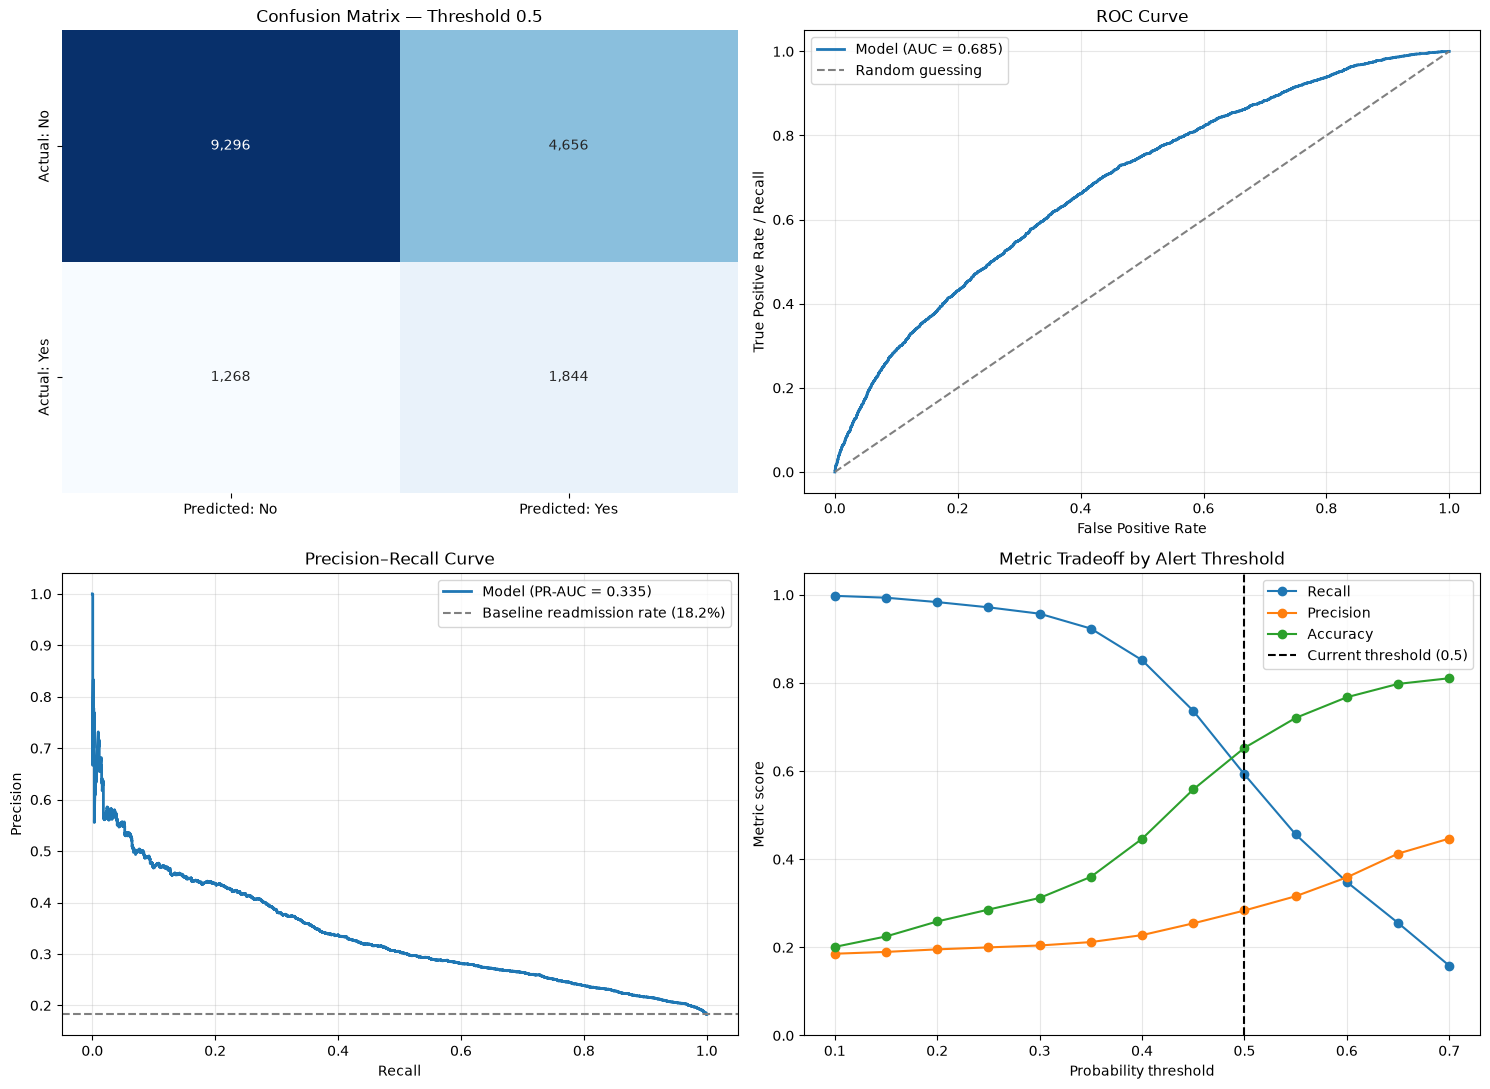

In [78]:

# ==========================================================
# Readmission model: vitals + labs + history
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
)
from xgboost import XGBClassifier


# 1. Select safe features
feature_columns = [
    # Admission-time features
    "first_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # Prior-history features
    "days_since_previous_discharge",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
    "prior_admission_count",
    "previous_hospital_los_days",

    # First-24-hour vitals
    *vital_feature_columns,

    # First-24-hour labs
    *lab_feature_columns,

    # First-24-hour urine output
    *urine_output_feature_columns,
    *input_feature_columns,

     # Prior comorbidity history
    *prior_diagnosis_feature_columns,

    # First-24-hour microbiology
    *microbiology_feature_columns,

    # First-24-hour prescription burden
    *medication_feature_columns,
]


missing_columns = [
    column
    for column in feature_columns
    if column not in readmit_cohort.columns
]

if missing_columns:
    raise ValueError(f"Missing feature columns: {missing_columns}")

X = readmit_cohort[feature_columns].copy()
y = readmit_cohort["readmit_30d"].copy()
groups = readmit_cohort["subject_id"].copy()

print(f"Total rows: {len(X):,}")
print(f"Features: {X.shape[1]}")
print(f"Overall 30-day readmission rate: {y.mean():.2%}")


# 2. Patient-safe split
splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_index, test_index = next(
    splitter.split(X, y, groups=groups)
)

X_train = X.iloc[train_index].copy()
X_test = X.iloc[test_index].copy()

y_train = y.iloc[train_index].copy()
y_test = y.iloc[test_index].copy()

print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

train_patients = set(groups.iloc[train_index])
test_patients = set(groups.iloc[test_index])

print(f"Patients shared by train and test: {len(train_patients & test_patients)}")


# 3. Preprocess numbers and text
categorical_features = X_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_train.columns.difference(
    categorical_features
).tolist()

numeric_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("one_hot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
)


# 4. Train XGBoost
number_of_zeros = (y_train == 0).sum()
number_of_ones = (y_train == 1).sum()

scale_pos_weight = number_of_zeros / number_of_ones

print(f"scale_pos_weight: {scale_pos_weight:.3f}")

readmit_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
)

readmit_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", readmit_model),
])

readmit_pipeline.fit(X_train, y_train)

print("Model training complete.")


# 5. Predictions and metrics
y_pred_proba = readmit_pipeline.predict_proba(X_test)[:, 1]

threshold = 0.50
y_pred = (y_pred_proba >= threshold).astype(int)

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F1 score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_pred_proba),
    "PR-AUC": average_precision_score(y_test, y_pred_proba),
}

print(f"\nMetrics at threshold = {threshold}")

for name, value in metrics.items():
    print(f"{name:<10}: {value:.3f}")


# 6. Threshold comparison
threshold_values = np.arange(0.10, 0.71, 0.05)
threshold_results = []

for t in threshold_values:
    predicted_at_t = (y_pred_proba >= t).astype(int)

    threshold_results.append({
        "threshold": t,
        "recall": recall_score(y_test, predicted_at_t, zero_division=0),
        "precision": precision_score(y_test, predicted_at_t, zero_division=0),
        "accuracy": accuracy_score(y_test, predicted_at_t),
        "f1": f1_score(y_test, predicted_at_t, zero_division=0),
    })

threshold_results = pd.DataFrame(threshold_results)

print("\nThreshold comparison:")
print(threshold_results.round(3).to_string(index=False))


# 7. Plots
cm = confusion_matrix(y_test, y_pred)
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)

precision_curve, recall_curve, _ = precision_recall_curve(
    y_test,
    y_pred_proba,
)

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Confusion matrix
sns.heatmap(
    cm,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    ax=axes[0, 0],
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)
axes[0, 0].set_title(f"Confusion Matrix — Threshold {threshold}")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("")

# ROC curve
axes[0, 1].plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Model (AUC = {metrics['ROC-AUC']:.3f})",
)
axes[0, 1].plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    label="Random guessing",
)
axes[0, 1].set_title("ROC Curve")
axes[0, 1].set_xlabel("False Positive Rate")
axes[0, 1].set_ylabel("True Positive Rate / Recall")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# Precision-recall curve
baseline_rate = y_test.mean()

axes[1, 0].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    label=f"Model (PR-AUC = {metrics['PR-AUC']:.3f})",
)
axes[1, 0].axhline(
    baseline_rate,
    linestyle="--",
    color="gray",
    label=f"Baseline readmission rate ({baseline_rate:.1%})",
)
axes[1, 0].set_title("Precision–Recall Curve")
axes[1, 0].set_xlabel("Recall")
axes[1, 0].set_ylabel("Precision")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# Threshold tradeoff
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["recall"],
    marker="o",
    label="Recall",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    marker="o",
    label="Precision",
)
axes[1, 1].plot(
    threshold_results["threshold"],
    threshold_results["accuracy"],
    marker="o",
    label="Accuracy",
)
axes[1, 1].axvline(
    threshold,
    linestyle="--",
    color="black",
    label=f"Current threshold ({threshold})",
)
axes[1, 1].set_title("Metric Tradeoff by Alert Threshold")
axes[1, 1].set_xlabel("Probability threshold")
axes[1, 1].set_ylabel("Metric score")
axes[1, 1].set_ylim(0, 1.05)
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

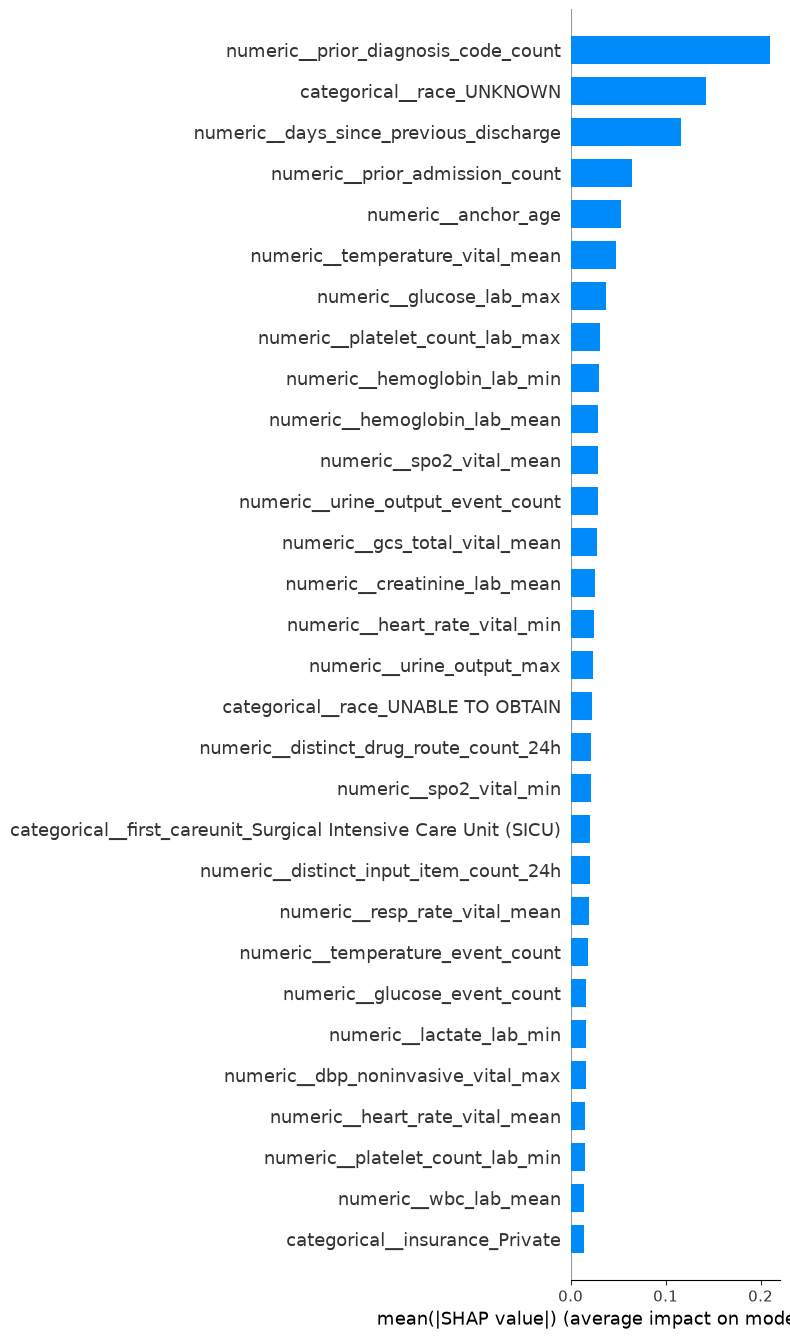

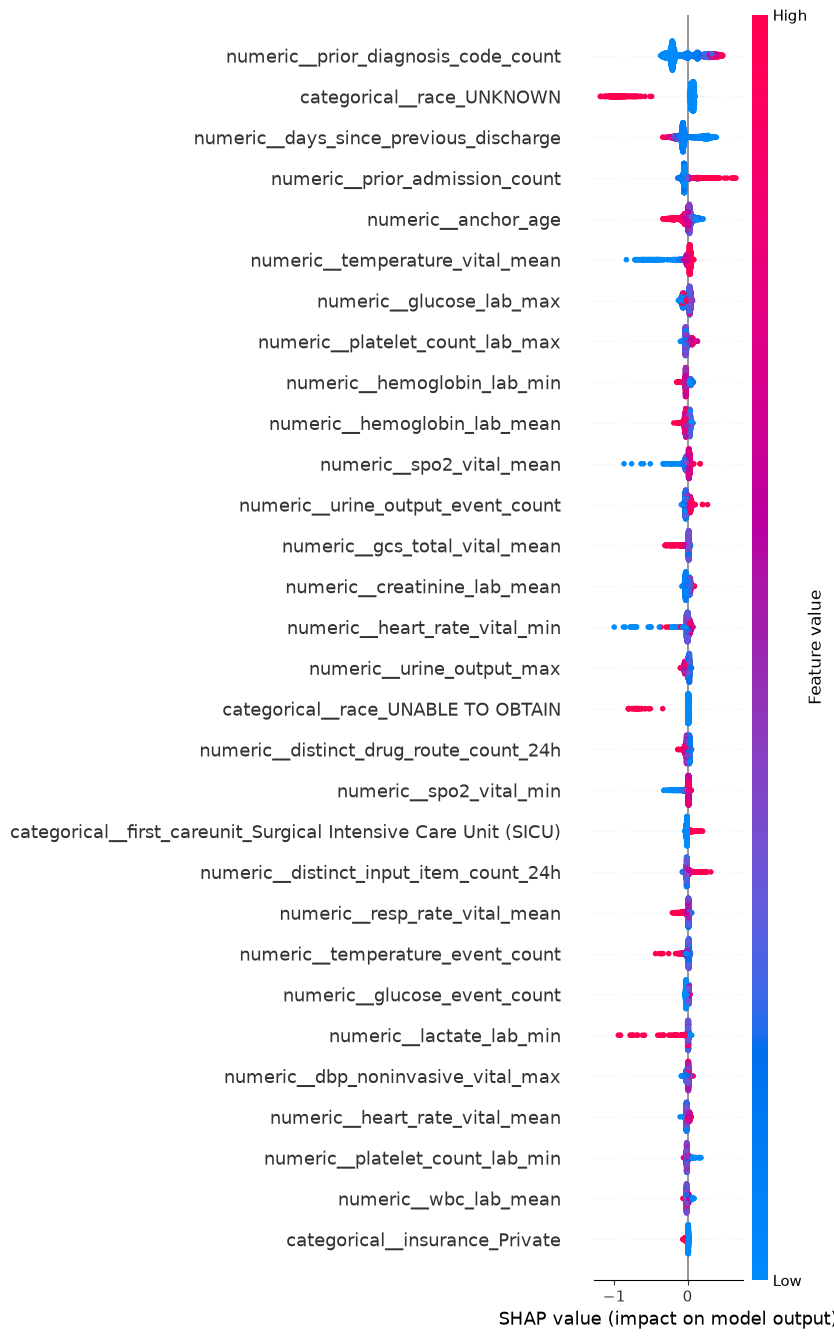

In [79]:
X_explain = X_test.sample(n=2000, random_state=42)

# Apply the exact preprocessing learned from X_train
X_explain_encoded = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .transform(X_explain)
)

# Get readable feature names after one-hot encoding
encoded_feature_names = (
    readmit_pipeline
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Convert sparse matrix into a normal dataframe for SHAP
if hasattr(X_explain_encoded, "toarray"):
    X_explain_encoded = X_explain_encoded.toarray()

X_explain_encoded = pd.DataFrame(
    X_explain_encoded,
    columns=encoded_feature_names,
    index=X_explain.index,
)

# Pull the trained XGBoost model out of the pipeline
trained_xgb_model = readmit_pipeline.named_steps["model"]

# Calculate SHAP values
explainer = shap.TreeExplainer(trained_xgb_model)
shap_values = explainer.shap_values(X_explain_encoded)

# Compatibility with some older SHAP versions
if isinstance(shap_values, list):
    shap_values = shap_values[1]

# ----------------------------------------------------------
# 1. Global feature-importance ranking
# ----------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_explain_encoded,
    plot_type="bar",
    max_display=30,
)

# ----------------------------------------------------------
# 2. Feature direction and impact
# ----------------------------------------------------------

shap.summary_plot(
    shap_values,
    X_explain_encoded,
    max_display=30,
)

In [80]:
# ==========================================================
# Validation split + feature-group ablation experiment
# ==========================================================

import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from xgboost import XGBClassifier


# ----------------------------------------------------------
# 1. Define the feature groups
# ----------------------------------------------------------

base_feature_columns = [
    # Admission-time features
    "first_careunit",
    "gender",
    "anchor_age",
    "admission_type",
    "admission_location",
    "insurance",
    "language",
    "marital_status",
    "race",

    # Prior admission / ICU history
    "days_since_previous_discharge",
    "mean_prior_hospital_los_days",
    "prior_icu_admission_count",
    "prior_icu_stay_count",
    "prior_admission_count",
    "previous_hospital_los_days",

    # First-24-hour clinical features
    *vital_feature_columns,
    *lab_feature_columns,
    *urine_output_feature_columns,
    *input_feature_columns,
]

feature_configs = {
    "A. Base clinical model": base_feature_columns,

    "B. Base + prior diagnoses": [
        *base_feature_columns,
        *prior_diagnosis_feature_columns,
    ],

    "C. Base + microbiology": [
        *base_feature_columns,
        *microbiology_feature_columns,
    ],

    "D. Base + prescriptions": [
        *base_feature_columns,
        *medication_feature_columns,
    ],

    "E. Base + all new groups": [
        *base_feature_columns,
        *prior_diagnosis_feature_columns,
        *microbiology_feature_columns,
        *medication_feature_columns,
    ],
}

# Confirm every requested feature exists
all_requested_columns = [
    column
    for config_columns in feature_configs.values()
    for column in config_columns
]

missing_columns = sorted(
    set(all_requested_columns)
    - set(readmit_cohort.columns)
)

if missing_columns:
    raise ValueError(
        f"These feature columns are missing:\n{missing_columns}"
    )

print("Feature counts by experiment:")

for name, columns in feature_configs.items():
    print(f"{name}: {len(columns)} features")


# ----------------------------------------------------------
# 2. Make patient-safe train / validation / final-test splits
# ----------------------------------------------------------

y_all = readmit_cohort["readmit_30d"].copy()
groups_all = readmit_cohort["subject_id"].copy()

# First split: 80% train+validation, 20% untouched final test
outer_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42,
)

train_validation_index, test_index = next(
    outer_splitter.split(
        readmit_cohort,
        y_all,
        groups=groups_all,
    )
)

train_validation_cohort = readmit_cohort.iloc[
    train_validation_index
].copy()

test_cohort = readmit_cohort.iloc[test_index].copy()

# Second split: 75% of train+validation = 60% total train
#               25% of train+validation = 20% total validation
inner_splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.25,
    random_state=42,
)

train_relative_index, validation_relative_index = next(
    inner_splitter.split(
        train_validation_cohort,
        train_validation_cohort["readmit_30d"],
        groups=train_validation_cohort["subject_id"],
    )
)

train_cohort = train_validation_cohort.iloc[
    train_relative_index
].copy()

validation_cohort = train_validation_cohort.iloc[
    validation_relative_index
].copy()

# Confirm no patient leakage
train_patients = set(train_cohort["subject_id"])
validation_patients = set(validation_cohort["subject_id"])
test_patients = set(test_cohort["subject_id"])

print("\nPatient-safe split sizes:")
print(f"Train:      {len(train_cohort):,} rows")
print(f"Validation: {len(validation_cohort):,} rows")
print(f"Final test: {len(test_cohort):,} rows")

print("\nShared patients:")
print(f"Train / validation: {len(train_patients & validation_patients)}")
print(f"Train / test:       {len(train_patients & test_patients)}")
print(f"Validation / test:  {len(validation_patients & test_patients)}")


# ----------------------------------------------------------
# 3. Reusable function: train one ablation model, score it
#    ONLY on validation data
# ----------------------------------------------------------

def train_and_validate(model_name, feature_columns):

    X_train = train_cohort[feature_columns].copy()
    y_train = train_cohort["readmit_30d"].copy()

    X_validation = validation_cohort[feature_columns].copy()
    y_validation = validation_cohort["readmit_30d"].copy()

    categorical_features = X_train.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    numeric_features = X_train.columns.difference(
        categorical_features
    ).tolist()

    numeric_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ])

    categorical_pipeline = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ],
    )

    scale_pos_weight = (
        (y_train == 0).sum()
        / (y_train == 1).sum()
    )

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)

    validation_probabilities = pipeline.predict_proba(
        X_validation
    )[:, 1]

    # Normal threshold and recall-first threshold
    predicted_050 = (
        validation_probabilities >= 0.50
    ).astype(int)

    predicted_045 = (
        validation_probabilities >= 0.45
    ).astype(int)

    results = {
        "model": model_name,
        "features": len(feature_columns),
        "validation_roc_auc": roc_auc_score(
            y_validation,
            validation_probabilities,
        ),
        "validation_pr_auc": average_precision_score(
            y_validation,
            validation_probabilities,
        ),
        "precision_at_050": precision_score(
            y_validation,
            predicted_050,
            zero_division=0,
        ),
        "recall_at_050": recall_score(
            y_validation,
            predicted_050,
            zero_division=0,
        ),
        "f1_at_050": f1_score(
            y_validation,
            predicted_050,
            zero_division=0,
        ),
        "precision_at_045": precision_score(
            y_validation,
            predicted_045,
            zero_division=0,
        ),
        "recall_at_045": recall_score(
            y_validation,
            predicted_045,
            zero_division=0,
        ),
    }

    return results, pipeline


# ----------------------------------------------------------
# 4. Run every ablation model on the same validation set
# ----------------------------------------------------------

ablation_results = []
ablation_models = {}

for model_name, columns in feature_configs.items():

    print(f"\nTraining: {model_name}")

    result, pipeline = train_and_validate(
        model_name,
        columns,
    )

    ablation_results.append(result)
    ablation_models[model_name] = pipeline

ablation_results = pd.DataFrame(
    ablation_results
).sort_values(
    "validation_pr_auc",
    ascending=False,
).reset_index(drop=True)

print("\nAblation results, ranked by validation PR-AUC:")
print(ablation_results.round(3).to_string(index=False))

Feature counts by experiment:
A. Base clinical model: 104 features
B. Base + prior diagnoses: 111 features
C. Base + microbiology: 106 features
D. Base + prescriptions: 107 features
E. Base + all new groups: 116 features

Patient-safe split sizes:
Train:      51,075 rows
Validation: 17,103 rows
Final test: 17,064 rows

Shared patients:
Train / validation: 0
Train / test:       0
Validation / test:  0

Training: A. Base clinical model

Training: B. Base + prior diagnoses

Training: C. Base + microbiology

Training: D. Base + prescriptions

Training: E. Base + all new groups

Ablation results, ranked by validation PR-AUC:
                    model  features  validation_roc_auc  validation_pr_auc  precision_at_050  recall_at_050  f1_at_050  precision_at_045  recall_at_045
B. Base + prior diagnoses       111               0.678              0.328             0.283          0.572      0.378             0.254          0.724
   C. Base + microbiology       106               0.678             

In [81]:
# ==========================================================
# Final ablation: diagnoses + microbiology, no prescriptions
# ==========================================================

diagnosis_microbiology_columns = [
    *base_feature_columns,
    *prior_diagnosis_feature_columns,
    *microbiology_feature_columns,
]

result, pipeline = train_and_validate(
    "F. Base + diagnoses + microbiology",
    diagnosis_microbiology_columns,
)

ablation_models[
    "F. Base + diagnoses + microbiology"
] = pipeline

ablation_results = pd.concat(
    [
        ablation_results,
        pd.DataFrame([result]),
    ],
    ignore_index=True,
)

ablation_results = ablation_results.sort_values(
    "validation_pr_auc",
    ascending=False,
).reset_index(drop=True)

print(
    ablation_results
    .round(3)
    .to_string(index=False)
)

                             model  features  validation_roc_auc  validation_pr_auc  precision_at_050  recall_at_050  f1_at_050  precision_at_045  recall_at_045
         B. Base + prior diagnoses       111               0.678              0.328             0.283          0.572      0.378             0.254          0.724
            C. Base + microbiology       106               0.678              0.328             0.284          0.575      0.380             0.254          0.724
          E. Base + all new groups       116               0.677              0.327             0.282          0.571      0.377             0.253          0.726
F. Base + diagnoses + microbiology       113               0.678              0.327             0.285          0.575      0.381             0.252          0.722
            A. Base clinical model       104               0.676              0.325             0.283          0.571      0.378             0.254          0.722
           D. Base + prescriptions

In [82]:
# ==========================================================
# Hyperparameter tuning on validation data
# Feature set: Base + microbiology
# ==========================================================

selected_feature_columns = [
    *base_feature_columns,
    *microbiology_feature_columns,
]

def tune_and_validate(config_name, model_settings):

    X_train = train_cohort[selected_feature_columns].copy()
    y_train = train_cohort["readmit_30d"].copy()

    X_validation = validation_cohort[
        selected_feature_columns
    ].copy()

    y_validation = validation_cohort[
        "readmit_30d"
    ].copy()

    categorical_features = X_train.select_dtypes(
        include=["object", "string", "category"]
    ).columns.tolist()

    numeric_features = X_train.columns.difference(
        categorical_features
    ).tolist()

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                ]),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(steps=[
                    (
                        "imputer",
                        SimpleImputer(strategy="most_frequent"),
                    ),
                    (
                        "one_hot",
                        OneHotEncoder(handle_unknown="ignore"),
                    ),
                ]),
                categorical_features,
            ),
        ],
    )

    scale_pos_weight = (
        (y_train == 0).sum()
        / (y_train == 1).sum()
    )

    model = XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        **model_settings,
    )

    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])

    pipeline.fit(X_train, y_train)

    validation_probabilities = pipeline.predict_proba(
        X_validation
    )[:, 1]

    predicted_050 = (
        validation_probabilities >= 0.50
    ).astype(int)

    predicted_045 = (
        validation_probabilities >= 0.45
    ).astype(int)

    return {
        "config": config_name,
        "settings": str(model_settings),
        "validation_roc_auc": roc_auc_score(
            y_validation,
            validation_probabilities,
        ),
        "validation_pr_auc": average_precision_score(
            y_validation,
            validation_probabilities,
        ),
        "precision_at_050": precision_score(
            y_validation,
            predicted_050,
            zero_division=0,
        ),
        "recall_at_050": recall_score(
            y_validation,
            predicted_050,
            zero_division=0,
        ),
        "f1_at_050": f1_score(
            y_validation,
            predicted_050,
            zero_division=0,
        ),
        "precision_at_045": precision_score(
            y_validation,
            predicted_045,
            zero_division=0,
        ),
        "recall_at_045": recall_score(
            y_validation,
            predicted_045,
            zero_division=0,
        ),
    }, pipeline


# Different XGBoost learning settings to compare
tuning_configs = {
    "1. Current baseline": {
        "n_estimators": 300,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },

    "2. Shallower trees": {
        "n_estimators": 400,
        "max_depth": 3,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },

    "3. Deeper trees": {
        "n_estimators": 300,
        "max_depth": 5,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },

    "4. Slower learning": {
        "n_estimators": 500,
        "max_depth": 4,
        "learning_rate": 0.03,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
    },

    "5. More regularization": {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5,
        "reg_lambda": 5,
        "reg_alpha": 0.1,
    },

    "6. Fewer columns per tree": {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.8,
        "colsample_bytree": 0.6,
    },

    "7. More row sampling": {
        "n_estimators": 400,
        "max_depth": 4,
        "learning_rate": 0.05,
        "subsample": 0.9,
        "colsample_bytree": 0.8,
    },
}

tuning_results = []
tuned_models = {}

for config_name, model_settings in tuning_configs.items():

    print(f"\nTraining: {config_name}")

    result, pipeline = tune_and_validate(
        config_name,
        model_settings,
    )

    tuning_results.append(result)
    tuned_models[config_name] = pipeline

tuning_results = pd.DataFrame(
    tuning_results
).sort_values(
    "validation_pr_auc",
    ascending=False,
).reset_index(drop=True)

print("\nHyperparameter-tuning results:")
print(tuning_results.round(3).to_string(index=False))


Training: 1. Current baseline

Training: 2. Shallower trees

Training: 3. Deeper trees

Training: 4. Slower learning

Training: 5. More regularization

Training: 6. Fewer columns per tree

Training: 7. More row sampling

Hyperparameter-tuning results:
                   config                                                                                                                                                          settings  validation_roc_auc  validation_pr_auc  precision_at_050  recall_at_050  f1_at_050  precision_at_045  recall_at_045
       4. Slower learning                                                           {'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'subsample': 0.8, 'colsample_bytree': 0.8}               0.678              0.330             0.284          0.578      0.381             0.253          0.724
      1. Current baseline                                                           {'n_estimators': 300, 'max_depth': 4, 'learning_rate': 

Threshold chosen from VALIDATION data:
Threshold: 0.45
Validation recall:    0.724
Validation precision: 0.253
Validation F1:        0.375

Final model trained on train + validation data.

FINAL TEST RESULTS
This is the first and only evaluation on test_cohort.

Threshold : 0.450
Accuracy  : 0.557
Precision : 0.255
Recall    : 0.742
F1 score  : 0.379
ROC-AUC   : 0.687
PR-AUC    : 0.337

Final confusion matrix:
[[7201 6751]
 [ 804 2308]]


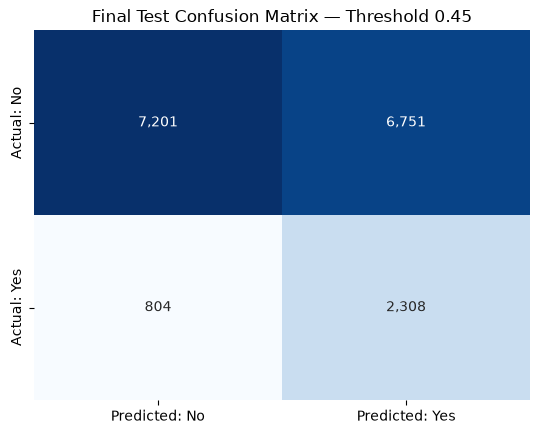

In [83]:
# ==========================================================
# Final threshold selection + final untouched test evaluation
# ==========================================================

# ----------------------------------------------------------
# 1. Select threshold using VALIDATION data only
# ----------------------------------------------------------

best_config_name = "4. Slower learning"

best_validation_pipeline = tuned_models[best_config_name]

X_validation_final = validation_cohort[
    selected_feature_columns
].copy()

y_validation_final = validation_cohort[
    "readmit_30d"
].copy()

validation_probabilities = (
    best_validation_pipeline
    .predict_proba(X_validation_final)[:, 1]
)

threshold_grid = np.arange(0.10, 0.71, 0.01)
validation_threshold_results = []

for threshold in threshold_grid:

    validation_predictions = (
        validation_probabilities >= threshold
    ).astype(int)

    validation_threshold_results.append({
        "threshold": threshold,
        "precision": precision_score(
            y_validation_final,
            validation_predictions,
            zero_division=0,
        ),
        "recall": recall_score(
            y_validation_final,
            validation_predictions,
            zero_division=0,
        ),
        "f1": f1_score(
            y_validation_final,
            validation_predictions,
            zero_division=0,
        ),
    })

validation_threshold_results = pd.DataFrame(
    validation_threshold_results
)

# Recall-first rule:
# choose the highest threshold that still catches at least 70%
valid_recall_thresholds = validation_threshold_results[
    validation_threshold_results["recall"] >= 0.70
]

chosen_threshold = (
    valid_recall_thresholds
    .sort_values(
        ["threshold", "precision"],
        ascending=[False, False],
    )
    .iloc[0]["threshold"]
)

chosen_validation_row = validation_threshold_results[
    validation_threshold_results["threshold"] == chosen_threshold
].iloc[0]

print("Threshold chosen from VALIDATION data:")
print(f"Threshold: {chosen_threshold:.2f}")
print(f"Validation recall:    {chosen_validation_row['recall']:.3f}")
print(f"Validation precision: {chosen_validation_row['precision']:.3f}")
print(f"Validation F1:        {chosen_validation_row['f1']:.3f}")


# ----------------------------------------------------------
# 2. Retrain final model on train + validation data
# ----------------------------------------------------------

final_training_cohort = pd.concat(
    [train_cohort, validation_cohort],
    ignore_index=True,
)

X_final_train = final_training_cohort[
    selected_feature_columns
].copy()

y_final_train = final_training_cohort[
    "readmit_30d"
].copy()

X_final_test = test_cohort[
    selected_feature_columns
].copy()

y_final_test = test_cohort[
    "readmit_30d"
].copy()

categorical_features = X_final_train.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_features = X_final_train.columns.difference(
    categorical_features
).tolist()

final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
            ]),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(steps=[
                (
                    "imputer",
                    SimpleImputer(strategy="most_frequent"),
                ),
                (
                    "one_hot",
                    OneHotEncoder(handle_unknown="ignore"),
                ),
            ]),
            categorical_features,
        ),
    ],
)

final_scale_pos_weight = (
    (y_final_train == 0).sum()
    / (y_final_train == 1).sum()
)

final_model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=final_scale_pos_weight,
    random_state=42,

    # Best validation hyperparameters
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.8,
    colsample_bytree=0.8,
)

final_readmit_pipeline = Pipeline(steps=[
    ("preprocessor", final_preprocessor),
    ("model", final_model),
])

final_readmit_pipeline.fit(
    X_final_train,
    y_final_train,
)

print("\nFinal model trained on train + validation data.")


# ----------------------------------------------------------
# 3. Evaluate ONCE on untouched final test data
# ----------------------------------------------------------

final_test_probabilities = (
    final_readmit_pipeline
    .predict_proba(X_final_test)[:, 1]
)

final_test_predictions = (
    final_test_probabilities >= chosen_threshold
).astype(int)

final_metrics = {
    "Threshold": chosen_threshold,
    "Accuracy": accuracy_score(
        y_final_test,
        final_test_predictions,
    ),
    "Precision": precision_score(
        y_final_test,
        final_test_predictions,
        zero_division=0,
    ),
    "Recall": recall_score(
        y_final_test,
        final_test_predictions,
        zero_division=0,
    ),
    "F1 score": f1_score(
        y_final_test,
        final_test_predictions,
        zero_division=0,
    ),
    "ROC-AUC": roc_auc_score(
        y_final_test,
        final_test_probabilities,
    ),
    "PR-AUC": average_precision_score(
        y_final_test,
        final_test_probabilities,
    ),
}

print("\nFINAL TEST RESULTS")
print("This is the first and only evaluation on test_cohort.\n")

for name, value in final_metrics.items():
    print(f"{name:<10}: {value:.3f}")

final_confusion_matrix = confusion_matrix(
    y_final_test,
    final_test_predictions,
)

print("\nFinal confusion matrix:")
print(final_confusion_matrix)

sns.heatmap(
    final_confusion_matrix,
    annot=True,
    fmt=",",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted: No", "Predicted: Yes"],
    yticklabels=["Actual: No", "Actual: Yes"],
)

plt.title(
    f"Final Test Confusion Matrix — Threshold {chosen_threshold:.2f}"
)

plt.xlabel("")
plt.ylabel("")
plt.show()

* Final Model:

Feature set:
Base clinical features + first-24-hour microbiology

Model:
XGBoost
n_estimators=500
max_depth=4
learning_rate=0.03

Threshold:
0.45

Final test:
Recall 74.2%
Precision 25.5%
ROC-AUC 0.687
PR-AUC 0.337